In [1]:
from pathlib import Path
from datetime import datetime

In [2]:
### PARAMETERS

smoothing_days = 90

time_smoothing = f'{smoothing_days}D'
lat_bounds = (25, 30)

test_start_year = 2005
test_end_year = 2020
validation_years_on_each_side = 10


target_reference_level = 4800

missing_values_in_target = False


using_missing_indices = False
using_transport_from_previous_year = False
use_deep_dvdz = False
deep_argo = True


train_batch_sizes = {
    '10D': 32,
    '30D': 16,
    '90D': 8,
    '365D': 4,
}


n_compartments_for_smoothing = {
    '10D': 49,
    '30D': 3,
    '90D': 9,
    '365D': 42,
}

train_batch_size = train_batch_sizes[time_smoothing]

add_tmp = False
add_sal = False

test_start_year = 2005
test_end_year = 2020

validation_years_on_each_side = 10


random_split_data = False

assert target_reference_level in [2000, 4800], "Only 2000 and 4800 are supported as reference levels"
version = 'v5'
n_compartments = n_compartments_for_smoothing[time_smoothing]
n_embedding = 8

distance_assignment_module  = 'distance'

experiment_path = Path(f'../rapid-geostrophic-reconstruction/figs/experiment_{datetime.now().strftime("%Y%m%d_%H%M%S")}')
dataset_path = Path(f'../rapid-geostrophic-reconstruction/datasets/smoothing_{smoothing_days}_days/argo_after_2012/base_sample/')

total_moc_path = Path('../rapid-geostrophic-reconstruction/datasets/moc_total/')
antilles_current_path = Path('../rapid-geostrophic-reconstruction/datasets/antilles_current/')
florida_current_path = Path('../rapid-geostrophic-reconstruction/datasets/florida_current/')
wind_stress_path = Path('../rapid-geostrophic-reconstruction/datasets/windstress/')

ref_folder = f'{abs(target_reference_level)}m_ref'

compartments = [
        ['west_p', -76.74, -70, 'west'],
        ['mar_west_p', -60, -47, 'east'],
        ['mar_east_p', -47, -40, 'west'],
        ['east_p', -30, -13.5, 'east']
    ]


device = 'cpu'


assert version in ['v2', 'v3', 'v4', 'v5']
assert distance_assignment_module in ['distance', 'fixed']



In [3]:
from amoc_reconstruction.reconstruction.dataset import load_merged_argo_dataset_and_tumo_cycles, filter_ds_argo_data, split_dataset_into_training_validation_testing_profile_datasets



ds_argo_merged, t_umo_obs, ds_pos_sim, dv_dz_obs, t_delta, total_moc, antilles_current, florida_current, wind_stress = load_merged_argo_dataset_and_tumo_cycles(
    ['1st_70None', '2nd_NoneNone'],
    dataset_path,
    ref_folder,
    total_moc_path,
    antilles_current_path,
    florida_current_path,
    wind_stress_path,
    time_smoothing,
    deep_argo,
    missing_values_in_target
)


ds_argo_merged = filter_ds_argo_data(ds_argo_merged, deep_argo)





train_dataset, val_dataset, test_dataset, (total_moc_mean, total_moc_std) = split_dataset_into_training_validation_testing_profile_datasets(
    False, test_start_year, test_end_year, validation_years_on_each_side, t_umo_obs, ds_argo_merged, add_tmp, add_sal, deep_argo, False, total_moc, florida_current, antilles_current, wind_stress, dv_dz_obs, missing_values_in_target, ds_pos_sim, compartments, time_smoothing, lat_bounds, using_transport_from_previous_year, using_missing_indices, use_deep_dvdz
)

from torch.utils.data import DataLoader
from amoc_reconstruction.reconstruction.dataset import merge_profiles_max_profiles

dl = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True, collate_fn=merge_profiles_max_profiles, num_workers=8)
val_dl = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles_max_profiles, num_workers=4)
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles_max_profiles, num_workers=4)



n_features = train_dataset.X.shape[2]


from amoc_reconstruction.reconstruction.model import init_assignment_module
from amoc_reconstruction.reconstruction.model import ProfileModelSUSTeR5_fast, ProfileModelSUSTeR6

node_assigner = init_assignment_module(distance_assignment_module, train_dataset, n_compartments, device)

if version == 'v5':
    model = ProfileModelSUSTeR5_fast(
        n_features, n_compartments,n_embedding, 
        train_dataset.dv_dz.shape[1] , dv_dz_obs.z, device, profile_embedder=None, node_assigner= node_assigner).to(device)
    print('model v5')
elif version == 'v6':
    model = ProfileModelSUSTeR6(
        n_features, n_compartments,n_embedding, 
        train_dataset.dv_dz.shape[1] , dv_dz_obs.z, device, profile_embedder=None, node_assigner= node_assigner).to(device)
    



from amoc_reconstruction.train import train, make_predictions


best_model = train(model, dl, val_dl, device)

test_predictions, (test_hidden_spaces, test_embedding_spaces, test_gt_transport, test_inner_values) = make_predictions(test_dataset, best_model, ds_argo_merged.isel(time = test_dataset.global_indices).time, total_moc_mean, total_moc_std,device = device)


target_variable = test_gt_transport

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

mae_error = mean_absolute_error(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)
print(f'R2 {r2_score(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)*100:.2f}%; MAE {mae_error:.2f}; MSE {mean_squared_error(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values):.2f}')



/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/p

model v5
New best model found in epoch:  0 with val loss:  0.4889865716298421
New best model found in epoch:  1 with val loss:  0.39986785252888996
Epoch 2, Loss: 0.40248010409149254, Val loss: 0.4535195529460907, current learning rate: 1.00E-03
New best model found in epoch:  3 with val loss:  0.31336964170138043
New best model found in epoch:  5 with val loss:  0.3082770307858785
Epoch 5, Loss: 0.34018124775453046, Val loss: 0.3082770307858785, current learning rate: 1.00E-03
New best model found in epoch:  7 with val loss:  0.28083644310633343
New best model found in epoch:  8 with val loss:  0.26871586839358014
Epoch 8, Loss: 0.31767605329779064, Val loss: 0.26871586839358014, current learning rate: 1.00E-03
Epoch 11, Loss: 0.30846269327131187, Val loss: 0.26995065808296204, current learning rate: 1.00E-03
New best model found in epoch:  14 with val loss:  0.2616600642601649
Epoch 14, Loss: 0.278478685089133, Val loss: 0.2616600642601649, current learning rate: 5.00E-04
Setting sig

### Experiment 20012025


- First we need to find the most promising method for the recosntruction. 
- Therefore we will reconstruct the 90 days scales in multiple configurations: 
    - Model v6 
    - Model v5 argo_mean + std with n_compartments = [1,3,5,7,11,17]
    - Model v5 argo_std with n_compartments = [1,3,5,7,11,17]
    - Model v5 argo_std with n_compartments = [1,3,5,7,11,17] and argo_mean in the embedding

- Each run is executed 3 times and the mean and std is reported



In [4]:
# Load the argo_dataset and the ground truth dataset



# ds_argo_merged, t_umo_obs = load_merged_argo_dataset_and_tumo(time_smoothing)#, lat_bounds = lat_bounds)



suffixe = ['1st_70None', '2nd_NoneNone']
ds_argo_merged, t_umo_obs, ds_pos_sim, dv_dz_obs, t_delta, total_moc_ds, antilles_current, florida_current, wind_stress = load_merged_argo_dataset_and_tumo_cycles(suffixe, time_smoothing)

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


## Single Profile Processing

We will load the ds_argo_merged dataset as thre base where each prfoile in the ten day window is present.
THen we will create 4 embedding one for each of the moorings and each profile is assigned by distance to those emebeddings. 
Each profile will create based on the currtent state and its rho values a delta that will be added to the embedding.

In [5]:
from copy import deepcopy

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [7]:
ds_argo_merged_10days

<xarray.Dataset>
Dimensions:       (time: 487, pos: 691, z: 46)
Coordinates:
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 684 685 686 687 688 689 690
  * time          (time) datetime64[ns] 1970-04-01 1970-06-30 ... 2090-01-01
  * z             (z) float32 -5.875e+03 -5.625e+03 -5.375e+03 ... -9.454 -3.047
    lon           (time, pos) float32 -38.15 -38.25 -38.35 ... nan nan nan
    lat           (time, pos) float32 25.02 25.06 25.11 25.11 ... nan nan nan
    time_1d       (time, pos) datetime64[ns] 1970-04-08T12:00:00 ... NaT
    pressure      (z) float32 5.875e+03 5.625e+03 5.375e+03 ... 9.454 3.047
Data variables:
    temperature   (time, pos, z) float32 nan nan nan nan ... nan nan nan nan
    salinity      (time, pos, z) float32 nan nan nan nan ... nan nan nan nan
    profile_mask  (time, pos, z) float64 nan nan nan nan 1.0 ... nan nan nan nan
    ct            (time, pos, z) float64 nan nan nan nan ... nan nan nan nan
    rho           (time, pos, z) float64 nan nan nan nan ... nan nan nan nan

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/numpy/lib/nanfunctions.py

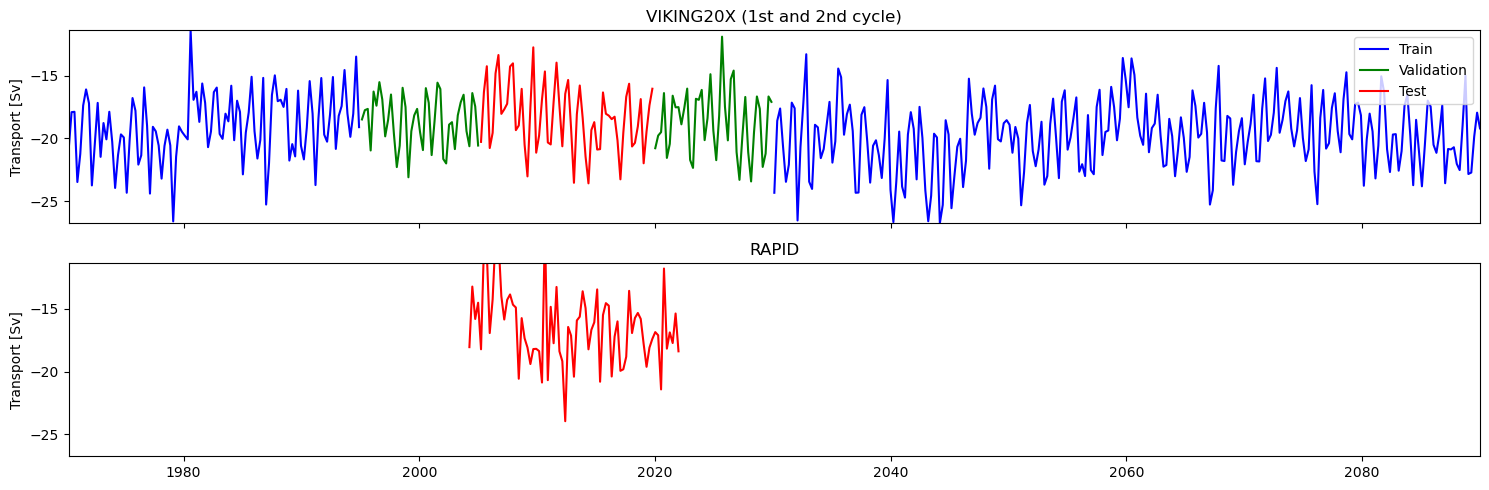

## Models

### SUSTeR LIB

In [12]:
#Original SUSTeR
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import math

class Align(nn.Module):
    def __init__(self, c_in, c_out):
        super(Align, self).__init__()
        self.c_in = c_in
        self.c_out = c_out
        self.align_conv = nn.Conv2d(
            in_channels=c_in, out_channels=c_out, kernel_size=(1, 1))

    def forward(self, x):
        if self.c_in > self.c_out:
            x = self.align_conv(x)
        elif self.c_in < self.c_out:
            batch_size, _, timestep, n_vertex = x.shape
            x = torch.cat([x, torch.zeros(
                [batch_size, self.c_out - self.c_in, timestep, n_vertex]).to(x)], dim=1)
        else:
            x = x

        return x


class CausalConv1d(nn.Conv1d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, enable_padding=False, dilation=1, groups=1, bias=True):
        if enable_padding == True:
            self.__padding = (kernel_size - 1) * dilation
        else:
            self.__padding = 0
        super(CausalConv1d, self).__init__(in_channels, out_channels, kernel_size=kernel_size,
                                           stride=stride, padding=self.__padding, dilation=dilation, groups=groups, bias=bias)

    def forward(self, input):
        result = super(CausalConv1d, self).forward(input)
        if self.__padding != 0:
            return result[:, :, : -self.__padding]

        return result


class CausalConv2d(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, enable_padding=False, dilation=1, groups=1, bias=True):
        kernel_size = nn.modules.utils._pair(kernel_size)
        stride = nn.modules.utils._pair(stride)
        dilation = nn.modules.utils._pair(dilation)
        if enable_padding == True:
            self.__padding = [int((kernel_size[i] - 1) * dilation[i])
                              for i in range(len(kernel_size))]
        else:
            self.__padding = 0
        self.left_padding = nn.modules.utils._pair(self.__padding)
        super(CausalConv2d, self).__init__(in_channels, out_channels, kernel_size,
                                           stride=stride, padding=0, dilation=dilation, groups=groups, bias=bias)

    def forward(self, input):
        if self.__padding != 0:
            input = F.pad(
                input, (self.left_padding[1], 0, self.left_padding[0], 0))
        result = super(CausalConv2d, self).forward(input)

        return result


class TemporalConvLayer(nn.Module):

    # Temporal Convolution Layer (GLU)
    #
    #        |--------------------------------| * Residual Connection *
    #        |                                |
    #        |    |--->--- CasualConv2d ----- + -------|
    # -------|----|                                   ⊙ ------>
    #             |--->--- CasualConv2d --- Sigmoid ---|
    #

    # param x: tensor, [bs, c_in, ts, n_vertex]

    def __init__(self, Kt, c_in, c_out, n_vertex, act_func):
        super(TemporalConvLayer, self).__init__()
        self.Kt = Kt
        self.c_in = c_in
        self.c_out = c_out
        self.n_vertex = n_vertex
        self.align = Align(c_in, c_out)
        if act_func == 'glu' or act_func == 'gtu':
            self.causal_conv = CausalConv2d(
                in_channels=c_in, out_channels=2 * c_out, kernel_size=(Kt, 1), enable_padding=False, dilation=1)
        else:
            self.causal_conv = CausalConv2d(in_channels=c_in, out_channels=c_out, kernel_size=(
                Kt, 1), enable_padding=False, dilation=1)
        self.act_func = act_func
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU()
        self.silu = nn.SiLU()

    def forward(self, x):
        x_in = self.align(x)[:, :, self.Kt - 1:, :]
        x_causal_conv = self.causal_conv(x)

        if self.act_func == 'glu' or self.act_func == 'gtu':
            x_p = x_causal_conv[:, : self.c_out, :, :]
            x_q = x_causal_conv[:, -self.c_out:, :, :]

            if self.act_func == 'glu':
                # GLU was first purposed in
                # *Language Modeling with Gated Convolutional Networks*.
                # URL: https://arxiv.org/abs/1612.08083
                # Input tensor X is split by a certain dimension into tensor X_a and X_b.
                # In the original paper, GLU is defined as Linear(X_a) ⊙ Sigmoid(Linear(X_b)).
                # However, in PyTorch, GLU is defined as X_a ⊙ Sigmoid(X_b).
                # URL: https://pytorch.org/docs/master/nn.functional.html#torch.nn.functional.glu
                # Because in original paper, the representation of GLU and GTU is ambiguous.
                # So, it is arguable which one version is correct.

                # (x_p + x_in) ⊙ Sigmoid(x_q)
                x = torch.mul((x_p + x_in), self.sigmoid(x_q))

            else:
                # Tanh(x_p + x_in) ⊙ Sigmoid(x_q)
                x = torch.mul(self.tanh(x_p + x_in), self.sigmoid(x_q))

        elif self.act_func == 'relu':
            x = self.relu(x_causal_conv + x_in)

        elif self.act_func == 'leaky_relu':
            x = self.leaky_relu(x_causal_conv + x_in)

        elif self.act_func == 'silu':
            x = self.silu(x_causal_conv + x_in)

        else:
            raise NotImplementedError(
                f'ERROR: The activation function {self.act_func} is not implemented.')

        return x


class ChebGraphConv(nn.Module):
    def __init__(self, c_in, c_out, Ks, bias):
        super(ChebGraphConv, self).__init__()
        self.c_in = c_in
        self.c_out = c_out
        self.Ks = Ks
        self.weight = nn.Parameter(torch.FloatTensor(Ks, c_in, c_out))
        if bias:
            self.bias = nn.Parameter(torch.FloatTensor(c_out))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self):
        init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            init.uniform_(self.bias, -bound, bound)

    def forward(self, x, gso):
        #bs, c_in, ts, n_vertex = x.shape
        x = torch.permute(x, (0, 2, 3, 1))

        gso = gso.to(x.device)

        if self.Ks - 1 < 0:
            raise ValueError(
                f'ERROR: the graph convolution kernel size Ks has to be a positive integer, but received {self.Ks}.')
        elif self.Ks - 1 == 0:
            x_0 = x
            x_list = [x_0]
        elif self.Ks - 1 == 1:
            x_0 = x
            x_1 = torch.einsum('bhi,btij->bthj', gso, x)
            x_list = [x_0, x_1]
        elif self.Ks - 1 >= 2:
            x_0 = x
            x_1 = torch.einsum('bhi,btij->bthj', gso, x)
            x_list = [x_0, x_1]
            for k in range(2, self.Ks):
                x_list.append(torch.einsum('bhi,btij->bthj', 2 *
                              gso, x_list[k - 1]) - x_list[k - 2])

        x = torch.stack(x_list, dim=2)

        cheb_graph_conv = torch.einsum('btkhi,kij->bthj', x, self.weight)

        if self.bias is not None:
            cheb_graph_conv = torch.add(cheb_graph_conv, self.bias)
        else:
            cheb_graph_conv = cheb_graph_conv

        return cheb_graph_conv


class GraphConv(nn.Module):
    def __init__(self, c_in, c_out, bias):
        super(GraphConv, self).__init__()
        self.c_in = c_in
        self.c_out = c_out
        self.weight = nn.Parameter(torch.FloatTensor(c_in, c_out))
        if bias:
            self.bias = nn.Parameter(torch.FloatTensor(c_out))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self):
        init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            init.uniform_(self.bias, -bound, bound)

    def forward(self, x, gso):
        #bs, c_in, ts, n_vertex = x.shape
        x = torch.permute(x, (0, 2, 3, 1))

        first_mul = torch.einsum('hi,btij->bthj', gso, x)
        second_mul = torch.einsum('bthi,ij->bthj', first_mul, self.weight)

        if self.bias is not None:
            graph_conv = torch.add(second_mul, self.bias)
        else:
            graph_conv = second_mul

        return graph_conv


class GraphConvLayer(nn.Module):
    def __init__(self, graph_conv_type, c_in, c_out, Ks, bias):
        super(GraphConvLayer, self).__init__()
        self.graph_conv_type = graph_conv_type
        self.c_in = c_in
        self.c_out = c_out
        self.align = Align(c_in, c_out)
        self.Ks = Ks
        if self.graph_conv_type == 'cheb_graph_conv':
            self.cheb_graph_conv = ChebGraphConv(c_out, c_out, Ks, bias)
        elif self.graph_conv_type == 'graph_conv':
            self.graph_conv = GraphConv(c_out, c_out, bias)

    def forward(self, x, gso):
        x_gc_in = self.align(x)
        if self.graph_conv_type == 'cheb_graph_conv':
            x_gc = self.cheb_graph_conv(x_gc_in, gso)
        elif self.graph_conv_type == 'graph_conv':
            x_gc = self.graph_conv(x_gc_in, gso)
        x_gc = x_gc.permute(0, 3, 1, 2)
        x_gc_out = torch.add(x_gc, x_gc_in)

        return x_gc_out


class STConvBlock(nn.Module):
    # STConv Block contains 'TGTND' structure
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # G: Graph Convolution Layer (ChebGraphConv or GraphConv)
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # D: Dropout

    def __init__(self, Kt, Ks, n_vertex, last_block_channel, channels, act_func, graph_conv_type, bias, droprate):
        super(STConvBlock, self).__init__()
        self.tmp_conv1 = TemporalConvLayer(
            Kt, last_block_channel, channels[0], n_vertex, act_func)
        self.graph_conv = GraphConvLayer(
            graph_conv_type, channels[0], channels[1], Ks, bias)
        self.tmp_conv2 = TemporalConvLayer(
            Kt, channels[1], channels[2], n_vertex, act_func)
        self.tc2_ln = nn.LayerNorm([n_vertex, channels[2]])
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=droprate)

    def forward(self, x, gso):
        x = self.tmp_conv1(x)
        x = self.graph_conv(x, gso)
        x = self.relu(x)
        x = self.tmp_conv2(x)
        x = self.tc2_ln(x.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)
        x = self.dropout(x)

        return x, gso


class OutputBlock(nn.Module):
    # Output block contains 'TNFF' structure
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # F: Fully-Connected Layer
    # F: Fully-Connected Layer

    def __init__(self, Ko, last_block_channel, channels, end_channel, n_vertex, act_func, bias, droprate):
        super(OutputBlock, self).__init__()
        self.tmp_conv1 = TemporalConvLayer(
            Ko, last_block_channel, channels[0], n_vertex, act_func)
        self.fc1 = nn.Linear(
            in_features=channels[0], out_features=channels[1], bias=bias)
        self.fc2 = nn.Linear(
            in_features=channels[1], out_features=end_channel, bias=bias)
        self.tc1_ln = nn.LayerNorm([n_vertex, channels[0]])
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU()
        self.silu = nn.SiLU()
        self.dropout = nn.Dropout(p=droprate)

    def forward(self, x):
        x = self.tmp_conv1(x)
        x = self.tc1_ln(x.permute(0, 2, 3, 1))
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x).permute(0, 3, 1, 2)

        return x


class ContextAwareMeanState(nn.Module):

    def __init__(self, n_proxy, n_embedding, n_context) -> None:
        super().__init__()

        self.n_proxy = n_proxy
        self.n_embedding = n_embedding

        self.fc1 = nn.Linear(n_context, n_embedding)
        self.fc2 = nn.Linear(n_embedding, n_proxy * n_embedding)


    def forward(self, context):

        global_embed = self.fc1(context)
        global_embed = F.relu(global_embed)

        Xbar = self.fc2(global_embed)

        return Xbar.reshape(-1, self.n_proxy, self.n_embedding)
    

class Embedding(nn.Module):

    def __init__(self, embed_dim, obs_dim, n_proxy) -> None:
        super().__init__()
        self.fc1_1 = nn.Linear(obs_dim + embed_dim * n_proxy, embed_dim)
        self.fc1_2 = nn.Linear(embed_dim , embed_dim)

        self.fc2_1 = nn.Linear(2, n_proxy)
        self.fc2_2 = nn.Linear(n_proxy, n_proxy)

        self.fc3_1 = nn.Linear(embed_dim, embed_dim)

        self.embed_dim = embed_dim
        self.n_proxy = n_proxy

    def forward(self, obs, v):
        
        ## Concat O and X for the embedding vector. 
        input = torch.concat((obs, v.reshape( -1).unsqueeze(dim = 0).expand(obs.shape[0], -1)), dim = -1)
        
        ## Create from the O and X the piece of information that should be incorporated into the network.
        x_emebdding = self.fc1_1(input)
        x_emebdding = F.relu(x_emebdding)
        x_emebdding = self.fc1_2(x_emebdding)
        x_emebdding = F.relu(x_emebdding)


        ## Use the position of the observations to find the best matching hidden node.
        positions = obs[..., :2]
        x_proxies = self.fc2_1(positions)
        x_proxies = F.relu(x_proxies)
        x_proxies = self.fc2_2(x_proxies)

        proxy_density = F.softmax(x_proxies, dim = -1) 

        ## Sample a single graph node from the created distributions and add the information to those nodes.
        sampled_proxy_index = torch.multinomial(proxy_density.reshape(-1, self.n_proxy), 1)
        mask = proxy_density#F.one_hot(sampled_proxy_index, num_classes = self.n_proxy).float().reshape(proxy_density.shape)
       
        obs_mask = torch.any(obs != 0, dim = -1).unsqueeze(dim=-1).expand(-1, self.n_proxy)
        mask = torch.mul(obs_mask, mask)

        new_information = self.fc3_1(x_emebdding)
        dotV_obs = torch.matmul(mask.unsqueeze(dim = -1), new_information.unsqueeze(dim = -2))

        return dotV_obs, mask

class SimpleOutput(nn.Module):

    def __init__(self, n_proxy, embed_dim, n_target) -> None:
        super().__init__()

        self.fc1 = nn.Linear(n_proxy * embed_dim, 256)
        self.fc2 = nn.Linear(256, 128)

        self.map = nn.Linear(128, n_target)

    def forward(self, VF, TP):

        x = self.fc1(VF)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        y = self.map(x)

        return y

class LocationBasedOutputv2(nn.Module):

    def __init__(self, n_proxy, embed_dim, targets) -> None:
        super().__init__()

        self.reduce = nn.Sequential(
            nn.Linear(n_proxy * embed_dim, 256),
            nn.ReLU(),
            nn.Linear(256,embed_dim)
        )

        self.proxy_porportion = nn.Sequential(
            nn.Linear(4 + embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_proxy)
        )
        self.fc3 = nn.Linear(embed_dim, embed_dim)
        self.map = nn.Linear(embed_dim, 1)

        self.n_proxy = n_proxy
        self.embed_dim = embed_dim


    def forward(self, VF, target_positions):

        global_state = self.reduce(VF).unsqueeze(dim = 1)
        pos_with_glob_state = torch.concat((global_state.expand(-1, target_positions.shape[0], -1), target_positions.unsqueeze(dim = 0).expand(VF.shape[0], -1, -1)), dim=-1)
        p_proxy = F.softmax(F.relu(self.proxy_porportion(pos_with_glob_state)), dim = -1)


        VF = VF.reshape(VF.shape[0], self.n_proxy, self.embed_dim)
        accumulated_information = torch.einsum('bsp,bpe->bse', p_proxy, VF)

        x = self.fc3(accumulated_information)
        x = F.relu(x)
        y = self.map(x) 

        return y

class mySequential(nn.Sequential):
    def forward(self, *input):
        for module in self._modules.values():
            input = module(*input)
        return input


class STGCNChebGraphConv(nn.Module):
    """
    Paper: Spatio-Temporal Graph Convolutional Networks: A Deep Learning Framework for Trafﬁc Forecasting
    Official Code: https://github.com/VeritasYin/STGCN_IJCAI-18 (tensorflow)
    Ref Code: https://github.com/hazdzz/STGCN
    Note:  
        https://github.com/hazdzz/STGCN/issues/9
    Link: https://arxiv.org/abs/1709.04875
    """

    # STGCNChebGraphConv contains 'TGTND TGTND TNFF' structure
    # ChebGraphConv is the graph convolution from ChebyNet.
    # Using the Chebyshev polynomials of the first kind as a graph filter.

    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # G: Graph Convolution Layer (ChebGraphConv)
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # D: Dropout

    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # G: Graph Convolution Layer (ChebGraphConv)
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # D: Dropout

    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normalization
    # F: Fully-Connected Layer
    # F: Fully-Connected Layer

    def __init__(self, Kt, Ks, blocks, T, n_vertex, act_func, graph_conv_type, bias, droprate):
        super(STGCNChebGraphConv, self).__init__()
        modules = []
        for l in range(len(blocks) - 3):
            modules.append(STConvBlock(
                Kt, Ks, n_vertex, blocks[l][-1], blocks[l+1], act_func, graph_conv_type, bias, droprate))
        self.st_blocks = mySequential(*modules)
        Ko = T - (len(blocks) - 3) * 2 * (Kt - 1)
        self.Ko = Ko
        assert Ko != 0, "Ko = 0."
        self.output = OutputBlock(
            Ko, blocks[-3][-1], blocks[-2], blocks[-1][0], n_vertex, act_func, bias, droprate)

    def forward(self, history_data: torch.Tensor, gso: torch.Tensor, **kwargs) -> torch.Tensor:
        """feedforward function of STGCN.

        Args:
            history_data (torch.Tensor): historical data with shape [B, L, N, C]

        Returns:
            torch.Tensor: prediction with shape [B, L, N, C]
        """
        x = history_data.permute(0, 3, 1, 2).contiguous()

        x, _ = self.st_blocks(x, gso)
        x = self.output(x)

        # x = x.transpose(2, 3)
        x = x.permute(0, 2, 3, 1)
        return x
    
    
    



class SUSTeR(nn.Module):


    def __init__(self, n_proxy, embed_dim, n_channels, target, context_meanstate = False, norm_adj = False, factor = 1) -> None:

        super().__init__()

        self.norm_adj = norm_adj
        self.n_proxy = n_proxy
        self.embed_dim = embed_dim

        if context_meanstate:
            self.mean_state = ContextAwareMeanState(n_proxy, embed_dim, 2)
        else:
            self.mean_state = nn.Parameter(torch.randn(size = (self.n_proxy, self.embed_dim)) * .5, requires_grad= True)

      
        self.embedding = Embedding(embed_dim, n_channels, n_proxy)
        self.factor = factor
        if factor is not None:
            self.stgcn = STGCNChebGraphConv(3, 3, [[embed_dim], [64//factor, 16//factor, 64//factor], [64//factor, 16//factor, 64//factor], [128//factor, 128//factor], [embed_dim]], 12, n_proxy, 'glu', 'cheb_graph_conv', True, .5)


        if np.isscalar(target):
            self.output = SimpleOutput(n_proxy, embed_dim, target)
        else:
            self.output = LocationBasedOutputv2(n_proxy, embed_dim, target)

        
    def forward(self, x):

        batch_embeddings = []
        
        for batch_i in range(len(x)):
            compartment_embeddings = []
            observations = x[batch_i]
            nT, nS, nC = observations.shape

         

            # 1. Get the mean state from the context information.
            if isinstance(self.mean_state, nn.Module):
                raise NotImplementedError("Not implemented yet")
                mean_state = self.mean_state(target_positions[:, 0, :2])
            else:
                mean_state = self.mean_state
                # mean_state = torch.tile(mean_state, dims = (nB, 1, 1))
            

            # 2. Create an graph for each of the provided timesteps
            delta_proxies = [mean_state] 
            p_densities = []

            for timestep in range(nT):
                
                obs_t = observations[timestep] # [sensors, channels]

                # 2.1 Embed each observation into an embedding for each of the proxies
                embeddings, proxy_density = self.embedding(obs_t, delta_proxies[-1].detach()) # [sensors, proxy * embed]

                p_densities.append(proxy_density)

                # 2.2 Sum over all the emebeddings which count to real observations
                mask_observations = torch.any(obs_t != 0, dim = -1).unsqueeze(dim=-1).unsqueeze(dim=-1).expand(-1, self.n_proxy, self.embed_dim) # [ sensors, 1, 1]
                embeddings_mul = torch.mul(embeddings , mask_observations.int()) # Set all the non existing observation to zero

                if mask_observations[..., 0,0].sum() == 0.0: 
                    delta_proxy_embedding = torch.zeros(size= (self.n_proxy, self.embed_dim), device = observations.device)
                else:
                    delta_proxy_embedding = torch.sum(embeddings_mul, dim = 0)
                delta_proxies.append(delta_proxy_embedding)


            delta_proxies = torch.stack(delta_proxies, dim = 0)
            graphs = torch.cumsum(delta_proxies, dim = 0)

            # 3. Calculate the laplace matrix for the graph sequence from the last hidden state.
            if not self.norm_adj:        
                adj_mx = torch.softmax(torch.relu(torch.einsum('pe,le->pl', graphs[-1], graphs[-1])), dim = -1)
            else:
                norm_graph = graphs[ -1]/ (torch.norm(graphs[-1], p = 2, dim = -1, keepdim= True) + 1e-6)
                adj_mx = torch.softmax(torch.relu(torch.einsum('pe,le->pl',norm_graph, norm_graph)), dim = -1)

            # 4. Use the wrapped STGNN for the forward propagation of information through the hidden spatio temporal graph.
            if self.factor is not None:
                full_state = self.stgcn(graphs[1:].unsqueeze(0), adj_mx.unsqueeze(0)).squeeze(0) # [1, p, e]
            else:
                full_state = torch.mean(graphs[1:], dim = 1)


            batch_embeddings.append(full_state)
            # 5. Project the full state onto the spatial domain
            # out = self.output(full_state.reshape( -1), target_positions)

        # return out.reshape(nB, 1, -1, 1), self.output(mean_state.reshape(nB, -1), target_positions).reshape(nB, 1, -1, 1)
        return torch.stack(batch_embeddings, dim = 0)

### SUSTER orig

In [13]:
class ProfileModelSUSTeRorig(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None, nT = 12):
        super(ProfileModelSUSTeRorig, self).__init__()
        self.n_compartments = n_compartments #* n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features  , 256)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.33)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        self.device = device

        self.nT = nT

        self.suster = SUSTeR(n_proxy = n_compartments, embed_dim = n_embedding, n_channels = n_features + 2, target = 1, context_meanstate = False, norm_adj = False, factor = 1)

    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0) # (n_profiles)

            days_batch = torch.cat(days[batch_i], dim = 0) # (n_profiles)  


            input_to_suster = torch.cat((
                lon_batch.reshape(-1,1), 
                days_batch.reshape(-1,1),
                x_batch, 
            ), dim = -1) 


            bounds = torch.linspace(-1, 1, self.nT + 1)
            temporal_input = []
            for b_min, b_max in zip(bounds[:-1], bounds[1:]):
                
                t_mask = (days_batch >= b_min) & (days_batch < b_max)
                temporal_input.append(input_to_suster[t_mask])

            max_len = max([len(t) for t in temporal_input])

            temporal_input = [torch.cat((t, torch.zeros(max_len - len(t), input_to_suster.shape[1]).to(self.device)), dim = 0) for t in temporal_input]

            temporal_input = torch.stack(temporal_input, dim = 0) # [t,s,f]
                

            full_state = self.suster(temporal_input.unsqueeze(dim = 0)) # [1, 1, p, e]

            embedding_all_profiles = full_state.squeeze_(dim = 0).squeeze_(dim = 0).flatten()

            embedding_all_profiles = torch.concat([embedding_all_profiles, torch.zeros_like(dv_dz[batch_i])], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x)

In [14]:
from torch import nn

class PredictionToTransportModel(nn.Module):

    def __init__(self, z_scale, mean_per_z, std_per_z ):
        super(PredictionToTransportModel, self).__init__()
        self.mean_per_z = torch.tensor(mean_per_z).float()
        self.std_per_z = torch.tensor(std_per_z).float()
        self.bottom_index = np.argmin(np.abs(z_scale - -4800).values)
        self.amoc_index = np.argmin(np.abs(z_scale - -1000).values)

    def forward(self, x):
        x = x * self.std_per_z + self.mean_per_z

        dv_dz_prediction = x


        velocity_aggregation = torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20
        velocity_at_level_of_no_motion = velocity_aggregation[:, [self.bottom_index]]
        return (
            -((torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20) -
            (torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20).flip(-1)[:, [self.bottom_index]]).cumsum(-1) * 20 / 1e6
        ).flip(-1)[:, self.amoc_index]


class CompartmentModel(nn.Module):

    def __init__(self, n_features, n_embedding):
        super(CompartmentModel, self).__init__()
        self.n_features = n_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_features + n_embedding + 1 + 1, 256)
        self.fc2 = nn.Linear(256, 128)
        self.dropout1 = nn.Dropout(p=.015)
        self.fc3 = nn.Linear(128, n_embedding)
        self.dropout2 = nn.Dropout(p=.15)
        self.fc4 = nn.Linear(n_embedding, n_embedding)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

class ProfileModel(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None):
        super(ProfileModel, self).__init__()
        self.n_compartments = n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * n_compartments +n_dvdz_features  , 256)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.33)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.compartment_models = nn.ModuleList([CompartmentModel(n_features, n_embedding) for _ in range(n_compartments)])
        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        self.lstms = nn.ModuleList([nn.LSTM(n_features + 2, n_embedding, batch_first = True, dropout = .25) for _ in range(n_compartments)])

        self.device = device


    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]
            for i in range(self.n_compartments):
                x_compartment = x_batch[i]


                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding, device = self.device).float())
                else:
                    if self.profile_embedder is not None:
                        x_compartment = self.profile_embedder(x_compartment)

                    input_to_layer = torch.cat((x_compartment, lon[batch_i][i].reshape(-1,1), days[batch_i][i].reshape(-1,1)), dim = -1)
                    output, (hn, cn) = self.lstms[i](input_to_layer)
                    compartment_embeddings.append(hn.squeeze(0))
                continue


                compartment_embedding = torch.zeros(self.n_embedding).float()
                compartment_embeddings_for_mean = []
                for x_profile, lon_profile, day_profile in zip(x_compartment, lon[batch_i][i], days[batch_i][i]):
                    
                    input_to_compartment_embedding = torch.cat([x_profile, compartment_embedding, lon_profile.unsqueeze(0), day_profile.unsqueeze(0)]).float()
                    

                    
                    compartment_embedding = compartment_embedding + self.compartment_models[i](input_to_compartment_embedding).float()
                #     compartment_embeddings_for_mean.append(self.compartment_models[i](input_to_compartment_embedding).float())
                
                # if len(compartment_embeddings_for_mean) < 1:
                #     compartment_embedding = torch.zeros(self.n_embedding).float()
                # else:
                #     compartment_embedding = torch.stack(compartment_embeddings_for_mean).mean(dim = 0)    
                # if len(x_compartment) > 0:
                #     compartment_embedding /= len(x_compartment)

                    compartment_embedding = torch.tanh(compartment_embedding)

                # compartment_embedding_norm = torch.norm(compartment_embedding, dim = -1, keepdim = True)
                # compartment_embedding = compartment_embedding / (compartment_embedding_norm + 1e-6)


                compartment_embeddings.append(compartment_embedding)

            embedding_all_profiles = torch.concat(compartment_embeddings +[torch.zeros_like(dv_dz[batch_i])], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x)
        



### SUSTeR


In [15]:
class ProfileModelSUSTeR(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None):
        super(ProfileModelSUSTeR, self).__init__()
        self.n_compartments = n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * n_compartments +n_dvdz_features  , 256)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.33)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.compartment_models = nn.ModuleList([CompartmentModel(n_features, n_embedding) for _ in range(n_compartments)])
        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        self.pre_lstms = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_features + 2, n_embedding),
                nn.ReLU(),
                nn.Linear(n_embedding, n_embedding)
            )
            for _ in range(n_compartments)])

        self.lstms = nn.ModuleList([nn.LSTM(n_embedding, n_embedding, batch_first = True, dropout = .25) for _ in range(n_compartments)])

        self.node_assigner = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, n_compartments),
            nn.Softmax(dim = -1)
        )
        self.device = device

    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)

            days_batch = torch.cat(days[batch_i], dim = 0).reshape(-1,1) # (n_profiles, 1)  

            node_assignments = self.node_assigner(torch.cat((lon_batch, days_batch), dim = -1)) # (n_profiles, n_compartments)

            # node_assignments = node_assignments > (1/ self.n_compartments)
            #.argmax(dim = -1)

            for i in range(self.n_compartments):
            
                mask = node_assignments[:, i] >= (1/self.n_compartments) * .75

                x_compartment = x_batch[mask]


                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding, device = self.device).float())
                else:
                    if self.profile_embedder is not None:
                        x_compartment = self.profile_embedder(x_compartment)

                    input_to_layer = torch.cat((x_compartment, lon_batch[mask].reshape(-1,1), days_batch[mask].reshape(-1,1)), dim = -1) 
                    input_to_layer = self.pre_lstms[i](input_to_layer)
                    # input_to_layer = input_to_layer * node_assignments[mask, i].reshape(-1,1)
                    output, (hn, cn) = self.lstms[i](input_to_layer)
                    compartment_embeddings.append(hn.squeeze(0))
                continue

            



            embedding_all_profiles = torch.concat(compartment_embeddings +[torch.zeros_like(dv_dz[batch_i])], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x)

### SUSTeRv2

In [16]:
class DistanceAssignerModule(nn.Module):
    def __init__(self, n_compartments, centers = None, sigmas_learnable = True):
        super(DistanceAssignerModule, self).__init__()
        self.n_compartments = n_compartments
        
        if centers is not None:
            self.centers = nn.Parameter(torch.tensor(centers), requires_grad = True)
        else:
            self.centers = nn.Parameter((torch.rand(self.n_compartments, 3) * torch.tensor([1,1,2]) - torch.tensor([0,0,1])), requires_grad = True)
        
        # self.sigma = nn.Parameter(torch.ones(1, self.n_compartments) * .1, requires_grad=True)
        self.sigmas = nn.Parameter(torch.ones(1, self.n_compartments, 3) * 1, requires_grad=sigmas_learnable)



    def forward(self, x):

        if len(x.shape) == 3:

            centers = self.centers.unsqueeze(0).unsqueeze(0)
            sigmas = torch.abs(self.sigmas.unsqueeze(0)) + 1e-6
        else:
            centers = self.centers.unsqueeze(0)
            sigmas = torch.abs(self.sigmas) + 1e-6

        dist = ((x.unsqueeze(-2) - centers) ** 2 / sigmas ** 2).sum(dim = -1)

        return torch.softmax(- dist, dim = -1)
        # return torch.softmax(- torch.cdist(x, self.centers) ** 2 / self.sigma ** 2, dim = -1)
        
        
   
    


    def get_adjacent_matrix(self):
        return torch.softmax(-torch.cdist(self.centers, self.centers) ** 2, dim = -1)

In [17]:
class AssignerModule(nn.Module):

    def __init__(self, lon_inner_boundaries, day_inner_boundaries):
        super(AssignerModule, self).__init__()

        self.lon_inner_boundaries = lon_inner_boundaries
        self.day_inner_boundaries = day_inner_boundaries

        assert len(lon_inner_boundaries) > 0 and len(day_inner_boundaries) > 0 and len(lon_inner_boundaries) == len(day_inner_boundaries)

        self.num_buckets = len(lon_inner_boundaries) - 1

        print(self.num_buckets)
        
    def forward(self, x):
        
        lon = x[..., 0]
        lat = x[..., 1]
        day = x[..., 2]
    
        lon_buckets = torch.bucketize(lon, self.lon_inner_boundaries)
        day_buckets = torch.bucketize(day, self.day_inner_boundaries)

        def merge_boundary_buckets(values):
            values = torch.minimum(values, torch.tensor( self.num_buckets))
            values = torch.maximum(values, torch.tensor(1)) -1 
            return values
        
        lon_buckets = merge_boundary_buckets(lon_buckets)
        day_buckets = merge_boundary_buckets(day_buckets)

        buckets = lon_buckets * self.num_buckets + day_buckets

        assignment = torch.nn.functional.one_hot(buckets, num_classes = self.num_buckets ** 2).float()
        return assignment.detach()


class ProfileModelSUSTeR2(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None, node_assigner = None):
        super(ProfileModelSUSTeR2, self).__init__()
        self.n_compartments = n_compartments #* n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features +4 +3, 64)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.0)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.0)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.compartment_models = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_features +2 +4, n_embedding), 
                nn.ReLU(), 
                nn.Linear(n_embedding, n_embedding), 
                nn.LayerNorm(n_embedding),
                nn.Tanh(), 

            ) for _ in range(self.n_compartments)])


        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

    

        if node_assigner is not None:
            self.node_assigner = node_assigner
        else:
            self.node_assigner = DistanceAssignerModule(n_compartments)
        self.device = device

    def forward(self, x, lon, lat, dv_dz, days, y_prev, missing_indices):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)

            days_batch = torch.cat(days[batch_i], dim = 0).reshape(-1,1) # (n_profiles, 1)  

            node_assignments = self.node_assigner(torch.cat((lon_batch, days_batch), dim = -1)) # (n_profiles, n_compartments)


            for i in range(self.n_compartments):
            
                mask = node_assignments[:, i] >= (1/self.n_compartments) #* .75

                x_compartment = x_batch[mask]




                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding, device = self.device).float())
                else:
                    if self.profile_embedder is not None:
                        x_compartment = self.profile_embedder(x_compartment)
                    input_to_layer = torch.cat(
                        (x_compartment, 
                         lon_batch[mask].reshape(-1,1), 
                         days_batch[mask].reshape(-1,1),
                         ), dim = -1) 
                    
                    weighted_mean = torch.sum(input_to_layer * node_assignments[mask, i].reshape(-1,1), axis = 0) / (torch.sum(node_assignments[mask, i]) + 1e-6)

                    weighted_mean = torch.cat(
                        (
                            weighted_mean, 
                            missing_indices[batch_i].reshape(-1).float(),
                        ), dim = -1
                    )

                    compartment_embeddings.append(self.compartment_models[i](self.dropout2(weighted_mean)))

            embedding_all_profiles = torch.concat(compartment_embeddings +[dv_dz[batch_i]] + [missing_indices[batch_i]] +[y_prev[batch_i]] , dim = 0)
            # embedding_all_profiles = torch.concat(compartment_embeddings +[dv_dz[batch_i]], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        embedding_all_profiles = self.dropout1(embedding_all_profiles)
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        # x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        # x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x), None

### SUSTeRv3


In [18]:
class GraphEmbed(nn.Module):
    def __init__(self,  graph_embedding_dim,  nodes_hidden_dim):
        super(GraphEmbed, self).__init__()

        # Setting from the paper
        self.graph_hidden_size = graph_embedding_dim

        # Embed graphs
        self.node_gating = nn.Sequential(
            nn.Linear(nodes_hidden_dim, 1), nn.Sigmoid()
        )
        self.node_to_graph = nn.Linear(nodes_hidden_dim, self.graph_hidden_size)

    def forward(self, x):
        # Input x has the shape (batch_size, num_metanodes, hidden_dim)
        # Output embedding has the shape (batch_size, graph_embedding_dim)

        x = self.node_gating(x) * self.node_to_graph(x)
        return x.sum(1)
    

class Profile_Encoder(nn.Module):
    
        def __init__(self, hidden, input_dim):
            super(Profile_Encoder, self).__init__()
            self.hidden = hidden
            self.fc1 = nn.Linear(input_dim, self.hidden)
            self.fc2 = nn.Linear(self.hidden, self.hidden)
            self.fc3 = nn.Linear(self.hidden, self.hidden)
    
        def forward(self, x):
            x = torch.relu(self.fc1(x))
            x = torch.relu(self.fc2(x))
            x = torch.relu(self.fc3(x))
            return x

In [19]:
ds_pos_sim.pos

<xarray.DataArray 'pos' (pos: 4)>
array(['west', 'east', 'marwest', 'mareast'], dtype=object)
Coordinates:
    lat      (pos) float64 26.55 26.56 24.51 24.52
    lon      (pos) float64 -76.69 -17.45 -49.8 -41.2
    name     (pos) object 'west' 'east' 'marwest' 'mareast'
  * pos      (pos) object 'west' 'east' 'marwest' 'mareast'

In [20]:
from sklearn.cluster import KMeans

class ProfileModelSUSTeR3(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None, node_assigner = None):
        super(ProfileModelSUSTeR3, self).__init__()
        self.n_compartments = n_compartments #* n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        # self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features  , 256)
        self.fc1 = nn.Linear(n_embedding + n_dvdz_features + 3 +4 , 64)
        # self.bn1 = nn.BatchNorm1d(num_features=256)
        # self.fc2 = nn.Linear(128,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.5)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.25)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder


        self.compartment_models = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_features +2 + n_embedding +4, n_embedding), 
                nn.ReLU(), 
                nn.Linear(n_embedding, n_embedding), 
                nn.LayerNorm(n_embedding),
                nn.Tanh(),

            ) for _ in range(self.n_compartments)])
        


        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        if node_assigner is not None:
            self.node_assigner = node_assigner
        else:
            self.node_assigner = DistanceAssignerModule(n_compartments)

        self.device = device

        self.nT = 12

        self.E1 = nn.Parameter(torch.randn(n_compartments, 16), requires_grad = True)
        self.E2 = nn.Parameter(torch.randn(n_compartments, 16), requires_grad = True)


        self.stgcn = STGCNChebGraphConv(3, 3, [[n_embedding], [n_embedding, n_embedding, n_embedding], [n_embedding, n_embedding // 2, n_embedding], [64, 64], [n_embedding]], self.nT, n_compartments, 'silu', 'cheb_graph_conv', True, 0.25)

        self.dropout_p_embeddings = .1

        self.g_embed = GraphEmbed(n_embedding, n_embedding)
        self.self_attn = nn.MultiheadAttention(n_embedding, 1)

        self.alpha = nn.Parameter(torch.tensor(0.5), requires_grad = False)

    def forward(self, x, lon, lat, dv_dz, days, y_prev, missing_indices):

        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)

            days_batch = torch.cat(days[batch_i], dim = 0).reshape(-1,1) # (n_profiles, 1)  

            node_assignments = self.node_assigner(torch.cat((lon_batch, days_batch), dim = -1)) # (n_profiles, n_compartments)

            for i in range(self.n_compartments):
            
                mask = node_assignments[:, i] >= (1/self.n_compartments) * .75

                x_compartment = x_batch[mask] # (profiles, features)

                bounds = torch.linspace(-1, 1, self.nT + 1)
                temporal_input = []


                t_masks = []
                for b_min, b_max in zip(bounds[:-1], bounds[1:]):        
                    t_mask = (days_batch[mask, 0] >= b_min) & (days_batch[mask, 0] < b_max)
                    t_masks.append(t_mask)  
                    temporal_input.append(
                        torch.cat([
                            x_compartment[t_mask],
                            lon_batch[mask][t_mask],
                            days_batch[mask][t_mask]
                        ], dim = -1)
                    )

                # max_len = max([len(t) for t in temporal_input])

                # temporal_input = [torch.cat((t, torch.zeros(max_len - len(t), x_batch.shape[1]).to(self.device)), dim = 0) for t in temporal_input]
                # temporal_input = torch.stack(temporal_input, dim = 0) # [t,s,f] 

                compartment_embeddings_t = [] # create the embeddings for each timestep for this one compartment
                for t in range(self.nT):

                    if len(temporal_input[t]) < 1:
                        compartment_embeddings_t.append(torch.zeros(self.n_embedding, device = self.device).float())
                    else:
                        if self.profile_embedder is not None:
                            x_compartment_t = self.profile_embedder(temporal_input[t][..., :-2])
                            x_compartment_t = torch.cat([x_compartment_t, temporal_input[t][..., -2:]], dim = -1)
                        else:
                            x_compartment_t = temporal_input[t]

                        weighted_mean = torch.sum(x_compartment_t * node_assignments[mask][t_masks[t], i].reshape(-1,1), axis = 0) / (torch.sum(node_assignments[mask][t_masks[t], i]) + 1e-6)
                        compartment_embeddings_t.append(
                            self.compartment_models[i](
                                
                                torch.cat([
                                    weighted_mean,
                                    compartment_embeddings_t[-1] if (len(compartment_embeddings_t) > 0 and False) else torch.zeros(self.n_embedding, device = self.device).float(),
                                    missing_indices[batch_i].reshape(-1)
                                ])
                            )
                        )

                compartment_embeddings_t = torch.stack(compartment_embeddings_t, dim = 0)#.cumsum(dim = 0) # (nT, embedding)
                compartment_embeddings.append(compartment_embeddings_t) 

            
                    
            graphs = torch.stack(compartment_embeddings, dim = 0) # (n_compartments, nT, embedding)
            
            graphs = torch.permute(graphs, [1, 0, 2]) # (nT, n_compartments, embedding)


            # laplace = torch.softmax(torch.relu(torch.mm(self.E1, self.E2.T)), dim = -1)
            # create laplace matrix from self-attention
            laplace_semantic = self.self_attn(
                graphs.sum(dim = 0), 
                graphs.sum(dim = 0), 
                graphs.sum(dim = 0)
            )[1]
            laplace_spatial = self.node_assigner.get_adjacent_matrix()

            laplace = (self.alpha * laplace_semantic + (1 - self.alpha) * laplace_spatial)

            # threshold the laplace matrix
            laplace = torch.where(laplace <= 1/self.n_compartments, torch.tensor(0.0).to(self.device), laplace)

            full_state = self.stgcn(graphs.unsqueeze(0), laplace.unsqueeze(0)).squeeze(0) # [1, p, e]
            embedded_graph = self.g_embed(full_state).squeeze(0)
            # dropout of nodes 
            if self.training and False:
                dropout_prob = torch.rand(self.n_compartments, device = self.device) > self.dropout_p_embeddings
                dropout_mask = dropout_prob.repeat(self.n_embedding, 1).T.flatten().float() * (1 / 1 -self.dropout_p_embeddings)

                full_state = full_state * dropout_mask

            embedding_all_profiles = torch.concat([embedded_graph ,dv_dz[batch_i], y_prev[batch_i], missing_indices[batch_i]], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        # embedding_all_profiles = self.dropout1(embedding_all_profiles)
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        # x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        # x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x), (x, embedding_all_profiles)

### SUSTeRv4

In [21]:
class ProfileModelSUSTeR4(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None, node_assigner = None):
        super(ProfileModelSUSTeR4, self).__init__()
        self.n_compartments = n_compartments #* n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        # self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features  , 256)
        self.fc1 = nn.Linear(n_embedding + n_dvdz_features + 3 +4 , 64)
        # self.bn1 = nn.BatchNorm1d(num_features=256)
        # self.fc2 = nn.Linear(128,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.5)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.25)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder


        self.compartment_models = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_features + 3 + n_embedding +4, n_embedding), 
                nn.ReLU(), 
                nn.Linear(n_embedding, n_embedding), 
                nn.Tanh(),
                nn.LayerNorm(n_embedding),

            ) for _ in range(self.n_compartments)])
        


        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        if node_assigner is not None:
            self.node_assigner = node_assigner
        else:
            self.node_assigner = DistanceAssignerModule(n_compartments)

        self.device = device

        self.nT = 12

        self.E1 = nn.Parameter(torch.randn(n_compartments, 16), requires_grad = True)
        self.E2 = nn.Parameter(torch.randn(n_compartments, 16), requires_grad = True)


        self.stgcn = STGCNChebGraphConv(3, 3, [[n_embedding], [n_embedding, n_embedding, n_embedding], [n_embedding * 2, n_embedding *2], [n_embedding]], self.nT, n_compartments, 'relu', 'cheb_graph_conv', True, 0.25)


        self.g_embed = GraphEmbed(n_embedding, n_embedding)
        self.self_attn = nn.MultiheadAttention(n_embedding, 1)

        self.alpha = nn.Parameter(torch.tensor(1.0), requires_grad = False)

    def forward(self, x, lon, lat, dv_dz, days, y_prev, missing_indices):

        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)
            lat_batch = torch.cat(lat[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)

            days_batch = torch.cat(days[batch_i], dim = 0).reshape(-1,1) # (n_profiles, 1)  

            node_assignments = self.node_assigner(torch.cat((lon_batch, lat_batch), dim = -1)) # (n_profiles, n_compartments)

            for i in range(self.n_compartments):
            
                mask = node_assignments[:, i] >= (1/self.n_compartments) * .75

                x_compartment = x_batch[mask] # (profiles, features)

                bounds = torch.linspace(-1, 1, self.nT + 1)
                temporal_input = []


                t_masks = []
                for b_min, b_max in zip(bounds[:-1], bounds[1:]):        
                    t_mask = (days_batch[mask, 0] >= b_min) & (days_batch[mask, 0] < b_max)
                    t_masks.append(t_mask)  
                    temporal_input.append(
                        torch.cat([
                            x_compartment[t_mask],
                            lon_batch[mask][t_mask],
                            lat_batch[mask][t_mask],
                            days_batch[mask][t_mask]
                        ], dim = -1)
                    )

                # max_len = max([len(t) for t in temporal_input])

                # temporal_input = [torch.cat((t, torch.zeros(max_len - len(t), x_batch.shape[1]).to(self.device)), dim = 0) for t in temporal_input]
                # temporal_input = torch.stack(temporal_input, dim = 0) # [t,s,f] 

                compartment_embeddings_t = [] # create the embeddings for each timestep for this one compartment
                for t in range(self.nT):

                    if len(temporal_input[t]) < 1:
                        compartment_embeddings_t.append(torch.zeros(self.n_embedding, device = self.device).float())
                    else:
                        if self.profile_embedder is not None:
                            x_compartment_t = self.profile_embedder(temporal_input[t][..., :-3])
                            x_compartment_t = torch.cat([x_compartment_t, temporal_input[t][..., -3:]], dim = -1)
                        else:
                            x_compartment_t = temporal_input[t]

                        weighted_mean = torch.sum(x_compartment_t * node_assignments[mask][t_masks[t], i].reshape(-1,1), axis = 0) / (torch.sum(node_assignments[mask][t_masks[t], i]) + 1e-6)

                        compartment_embeddings_t.append(
                            self.compartment_models[i](
                                torch.cat([
                                    weighted_mean,
                                    compartment_embeddings_t[-1] if (len(compartment_embeddings_t) > 0 and False) else torch.zeros(self.n_embedding, device = self.device).float(),
                                    missing_indices[batch_i].reshape(-1)
                                ])
                            )
                        )

                compartment_embeddings_t = torch.stack(compartment_embeddings_t, dim = 0)#.cumsum(dim = 0) # (nT, embedding)
                compartment_embeddings.append(compartment_embeddings_t) 

            
                    
            graphs = torch.stack(compartment_embeddings, dim = 0) # (n_compartments, nT, embedding)
            
            graphs = torch.permute(graphs, [1, 0, 2]) # (nT, n_compartments, embedding)


            # laplace = torch.softmax(torch.relu(torch.mm(self.E1, self.E2.T)), dim = -1)
            # create laplace matrix from self-attention
            _, laplace_semantic = self.self_attn(
                graphs.max(dim = 0)[0], 
                graphs.max(dim = 0)[0], 
                graphs.max(dim = 0)[0],
                need_weights = True
            )

            

            laplace_spatial = self.node_assigner.get_adjacent_matrix()

            laplace = (self.alpha * laplace_semantic + (1 - self.alpha) * laplace_spatial)

            # threshold the laplace matrix
            # laplace = torch.where(laplace <= 1/self.n_compartments, torch.tensor(0.0).to(self.device), laplace)


            full_state = self.stgcn(graphs.unsqueeze(0), laplace.unsqueeze(0)).squeeze(0) # [1, p, e]
            embedded_graph = self.g_embed(full_state).squeeze(0)

            embedding_all_profiles = torch.concat([embedded_graph ,dv_dz[batch_i], y_prev[batch_i], missing_indices[batch_i]], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        x = torch.relu(self.fc1(embedding_all_profiles))
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x), (x, embedding_all_profiles)

### SUSTeRv5

### Execution 

In [128]:



device = 'cuda' if torch.cuda.is_available() else 'cpu'

node_assigner = AssignerModule(
            lon_inner_boundaries = torch.linspace(0, 1, n_compartments+1).to(device),
            day_inner_boundaries = torch.linspace(0, 1, n_compartments+1).to(device)
        )

model = ProfileModelSUSTeR5_fast(train_X_scaled.shape[2], n_compartments ** 2, train_X_scaled.shape[2], train_dv_dz_moorings_scaled.shape[1], ds_argo_merged_10days.z, device, node_assigner= node_assigner).to(device)
model.float()


state_dict = deepcopy(model.state_dict())



for X, mask_padded, y, y_prev, lon, lat, dvdz, days, missing_indices, fs, ac, ws, total_amoc in dl:
    
    X, mask_padded, y, y_prev, lon, lat, dvdz, days, missing_indices, fs, ac, ws, total_amoc = move_data_to_device([X, mask_padded, y, y_prev, lon, lat, dvdz, days, missing_indices, fs, ac, ws, total_amoc], device)
    print(model(X, mask_padded, lon, lat, dvdz, days, y_prev, missing_indices, fs, ac, ws)[0].squeeze(), total_amoc)
    %timeit model(X, mask_padded, lon, lat, dvdz, days, y_prev, missing_indices, fs,ac,ws)#.squeeze()

    break


print(',\n'.join([f'{n}: {p.shape}' for n, p in model.named_parameters()]))

9


tensor([-0.1223, -0.2016, -0.1433, -0.1734,  0.0603, -0.1383, -0.1658, -0.1026],
       grad_fn=<SqueezeBackward0>) tensor([ 1.2836,  0.7891,  0.1380, -1.1616, -1.6230, -0.7763, -0.4332, -0.3140])
273 ms ± 12.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
E1: torch.Size([81, 8]),
E2: torch.Size([81, 8]),
alpha: torch.Size([]),
fc1.weight: torch.Size([64, 3784]),
fc1.bias: torch.Size([64]),
bn1.weight: torch.Size([256]),
bn1.bias: torch.Size([256]),
fc2.weight: torch.Size([64, 64]),
fc2.bias: torch.Size([64]),
fc3.weight: torch.Size([64, 64]),
fc3.bias: torch.Size([64]),
fc4.weight: torch.Size([64, 64]),
fc4.bias: torch.Size([64]),
bn2.weight: torch.Size([64]),
bn2.bias: torch.Size([64]),
fc5.weight: torch.Size([32, 64]),
fc5.bias: torch.Size([32]),
fc6.weight: torch.Size([1, 32]),
fc6.bias: torch.Size([1]),
compartment_models.0.0.weight: torch.Size([92, 46]),
compartment_models.0.0.bias: torch.Size([92]),
compartment_models.0.2.weight: torch.Size([46, 92]),
compartment_models.

In [129]:
import matplotlib.pyplot as plt

def test_assignments(epoch_i, na):

        lons = np.linspace(-80, -20, 100)
        lons_scaled = (lons - train_dataset.min_longitude) / (train_dataset.max_longitude - train_dataset.min_longitude)
        days = np.linspace(-45, 45, 100) 
        days_scaled = days / (pd.Timedelta(time_smoothing).days / 2)

        XX, YY = np.meshgrid(lons_scaled, days_scaled)
        labels = na( torch.tensor(np.stack([XX, YY], axis = -1).reshape(-1, 2)).float().to(device)).cpu().detach().numpy().argmax(axis = -1).reshape(XX.shape)

        fig, ax = plt.subplots(1, 1, figsize = (10, 5))

        cf = ax.pcolormesh(lons, days, labels,vmin = -.5, vmax = 19.5, cmap='tab20')

        plt.colorbar(cf, ticks = np.arange(0, 20))

        fig.savefig(f'../rapid-geostrophic-reconstruction/figs/node_assignments_{epoch_i}.png')

        plt.close(fig)

train_X_scaled.shape[2]

46

In [154]:
from torch import optim
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime


torch.random.manual_seed(42)
np.random.seed(42)

# version = 'v6'

# n_hidden = 8
# profile_embedder = Profile_Encoder(n_hidden, 29)
# profile_embedder.requires_grad_(False)
# profile_embedder.load_state_dict(torch.load(f'../rapid-geostrophic-reconstruction/profile_encoder_{n_hidden}dim_rho.pt'))
# profile_embedder = profile_embedder.to(device)

# model = ProfileModel(hidden, n_compartments, 64, train_dv_dz_moorings_scaled.shape[1] , ds_argo_merged_10days.z, device, profile_embedder).to(device)
n_features = train_X_scaled.shape[2]

if distance_assignment_module == 'distance':


    lons_in_training =       train_dataset.lon_scaled.flatten()
    lats_in_training =       train_dataset.lat_scaled.flatten()
    days_in_training =       train_dataset.days_scaled.flatten()

    mask = ~np.isnan(lons_in_training) & ~np.isnan(lats_in_training) & ~np.isnan(days_in_training)
    lons_in_training_nonnan = lons_in_training[mask]
    lats_in_training_nonnan = lats_in_training[mask]
    days_in_training_nonnan = days_in_training[mask]

    X_lonlatdays = np.stack([lons_in_training_nonnan, lats_in_training_nonnan, days_in_training_nonnan], axis = -1)
    kmeans = KMeans(n_clusters=n_compartments, random_state=0).fit(X_lonlatdays)
        
    node_assigner = DistanceAssignerModule(n_compartments, kmeans.cluster_centers_, sigmas_learnable= False)
elif distance_assignment_module == 'fixed' or True:
    node_assigner = AssignerModule(
            lon_inner_boundaries = torch.linspace(0, 1, n_compartments+1).to(device),
            day_inner_boundaries = torch.linspace(0, 1, n_compartments+1).to(device)
        )
    

if version == 'v2':
    model = ProfileModelSUSTeR2(n_features, n_compartments,n_embedding, train_dv_dz_moorings_scaled.shape[1] , ds_argo_merged_10days.z, device, None, node_assigner= node_assigner).to(device)
elif version == 'v3':
    model = ProfileModelSUSTeR3(
        n_features, n_compartments,n_embedding, 
        train_dv_dz_moorings_scaled.shape[1] , dv_dz_obs.z, device, profile_embedder=None, node_assigner= node_assigner).to(device)
elif version == 'v4':
    model = ProfileModelSUSTeR4(
        n_features, n_compartments,n_embedding, 
        train_dv_dz_moorings_scaled.shape[1] , dv_dz_obs.z, device, profile_embedder=None, node_assigner= node_assigner).to(device)
elif version == 'v5':
    model = ProfileModelSUSTeR5_fast(
        n_features, n_compartments,n_embedding, 
        train_dv_dz_moorings_scaled.shape[1] , dv_dz_obs.z, device, profile_embedder=None, node_assigner= node_assigner).to(device)
    print('model v5')
elif version == 'v6':
    model = ProfileModelSUSTeR6(
        n_features, n_compartments,n_embedding, 
        train_dv_dz_moorings_scaled.shape[1] , dv_dz_obs.z, device, profile_embedder=None, node_assigner= node_assigner).to(device)



model.float()
criterion = nn.L1Loss()

optimizer_all = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs = 200
lr_scheduler_all = optim.lr_scheduler.MultiStepLR(optimizer_all, milestones=[15,30, 80, 100, 150], gamma=.5)

writer = SummaryWriter(f'../rapid-geostrophic-reconstruction/runs/susterv3-{datetime.now().strftime("%Y-%m-%d_%H-%M")}')
best_val_loss = 1e10
best_model = None
best_epoch = 0

train_losses = []

torch.autograd.set_detect_anomaly(True)
# model.node_assigner.requires_grad_(False)

for epoch in range(num_epochs):  # loop over the dataset multiple times
    model.train()
    loss_per_epoch = 0.0

    # if (type(model.node_assigner) == DistanceAssignerModule) and epoch > 15 and model.node_assigner.sigmas.requires_grad:
    
    if epoch >= 15 and type(model) == ProfileModelSUSTeR5_fast:
        if (type(model.node_assigner) == DistanceAssignerModule) and ((epoch // 5) % 3) < 2  and epoch > 15:
            if model.node_assigner.sigmas.requires_grad:
                print('Setting sigmas to requires_grad=False')
                model.node_assigner.requires_grad_(False)
        else:
            if not model.node_assigner.sigmas.requires_grad:
                print('Setting sigmas to requires_grad=True')
                model.node_assigner.requires_grad_(True)
            # test_assignments(epoch, model.node_assigner)


    for i, data in enumerate(dl, 0):
        # get the inputs; data is a list of [inputs, labels]
        X, mask_padded, y, y_prev, lon, lat, dvdz, days, missing_indices, fs, ac, ws, total_moc = move_data_to_device(data, device)
        

        # zero the parameter gradients
        optimizer_all.zero_grad()

        outputs, _ = model(X, mask_padded, lon, lat, dvdz, days, y_prev, missing_indices, fs, ac, ws)
        loss = criterion(outputs, total_moc)
        loss.backward()

        optimizer_all.step()
        loss_per_epoch += loss.detach().cpu().item()

    lr_scheduler_all.step()

    model.eval()
    total_val_loss = 0.

    with torch.no_grad():
        for data in val_dl:
            X, mask_padded, y, y_prev, lon, lat, dvdz, days, missing_indices, fs, ac, ws, total_moc = move_data_to_device(data, device)
            val_prediction, _ = model(X, mask_padded, lon, lat, dvdz, days, y_prev, missing_indices, fs, ac, ws)
            # val_prediction = val_prediction.detach()
            val_loss = criterion(val_prediction, total_moc).detach().cpu().item()

            total_val_loss += val_loss

    total_val_loss /= len(val_dl)


    if total_val_loss < best_val_loss:
        best_val_loss = total_val_loss
        best_epoch = epoch
        best_model = deepcopy(model)
        print('New best model found in epoch: ', epoch, 'with val loss: ', total_val_loss)
        
        # test_assignments(epoch, model.node_assigner)

    if (epoch+1) % 3 == 0:
        print(f'Epoch {epoch}, Loss: {loss_per_epoch / len(dl)}, Val loss: {total_val_loss}, current learning rate: {optimizer_all.param_groups[0]["lr"]:.2E}')

    writer.add_scalars('Loss', {
        'train': loss_per_epoch / len(dl),
        'validation': total_val_loss}, epoch)

    train_losses.append([loss_per_epoch / len(dl), total_val_loss])

    if epoch - best_epoch > 25 and best_val_loss < 20:
        break


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


model v5
New best model found in epoch:  0 with val loss:  0.41309861342112225
New best model found in epoch:  1 with val loss:  0.33105699221293133
New best model found in epoch:  2 with val loss:  0.31881914536158246
Epoch 2, Loss: 0.40240137685428967, Val loss: 0.31881914536158246, current learning rate: 1.00E-03
New best model found in epoch:  5 with val loss:  0.31704715887705487
Epoch 5, Loss: 0.35429504987868393, Val loss: 0.31704715887705487, current learning rate: 1.00E-03
New best model found in epoch:  6 with val loss:  0.2948937714099884
New best model found in epoch:  7 with val loss:  0.27890215317408246
Epoch 8, Loss: 0.32969608665867284, Val loss: 0.2791311840216319, current learning rate: 1.00E-03
Epoch 11, Loss: 0.2939711883664131, Val loss: 0.3073371847470601, current learning rate: 1.00E-03
Epoch 14, Loss: 0.2955890473994342, Val loss: 0.29812828699747723, current learning rate: 5.00E-04
Setting sigmas to requires_grad=True
Setting sigmas to requires_grad=False
Epoc

In [155]:
last_model = deepcopy(model)



train_predictions, _ = make_predictions(train_dataset, best_model, train_indices)
val_predictionq, _ = make_predictions(val_dataset, best_model, val_indices)
test_predictions, (test_hidden_spaces, test_embedding_spaces, test_gt_transport, test_inner_values) = make_predictions(test_dataset, best_model, test_indices)


In [156]:
argo_numbers_per_compartment = np.empty((len(test_dataset), len(compartments)))

for i, (x, _, _, _, _, _, _, _, _, _, _, _) in enumerate(test_dataset):
    for j, x_compartment in enumerate(x):
        argo_numbers_per_compartment[i, j] = len(x_compartment)


argo_numbers_per_compartment = xr.DataArray(
    argo_numbers_per_compartment,
    coords = {
        'time': t_umo_10days.time.isel(time = test_indices)
    },
    dims = ['time', 'compartment'],
    name = 'argo_numbers_per_compartment'
)

### Results

In [157]:



(
    (   
    train_predictions.hvplot(label = 'train') *
    val_predictionq.hvplot(label = 'val') *
    test_predictions.hvplot(label = 'test') *
    # t_umo_obs.sel(time = test_predictions.time, method = 'nearest').hvplot(label = 'rapid')
    total_moc_max.hvplot(label = 'rapid')
        # * t_merged_argo_2000.sel(time = transport.time, method = 'nearest').hvplot(label = 'argo')
) +

(
    argo_numbers_per_compartment.isel(compartment = 0).hvplot(label = compartments[0][0]) *
    argo_numbers_per_compartment.isel(compartment = 1).hvplot(label = compartments[1][0]) *
    argo_numbers_per_compartment.isel(compartment = 2).hvplot(label = compartments[2][0]) *
    argo_numbers_per_compartment.isel(compartment = 3).hvplot(label = compartments[3][0])
)


).cols(1)

:Layout
   .Overlay.I  :Overlay
      .Curve.Train :Curve   [time]   (dv_dz_times_X)
      .Curve.Val   :Curve   [time]   (dv_dz_times_X)
      .Curve.Test  :Curve   [time]   (dv_dz_times_X)
      .Curve.Rapid :Curve   [time]   (Meridional_Overt.Cell_Atlantic)
   .Overlay.II :Overlay
      .Curve.West_p     :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_west_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_east_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.East_p     :Curve   [time]   (argo_numbers_per_compartment)

In [158]:
error = (test_predictions- t_umo_obs.sel(time = test_predictions.time, method = 'nearest'))

sorted_times = error.sortby('dv_dz_times_X')

((
    sorted_times.drop_vars('time').hvplot(x = 'time', y = 'dv_dz_times_X')
) + (
    argo_numbers_per_compartment.sel(time = sorted_times.time).isel(compartment = 0).drop_vars('time').rolling(time = 3, center = True).mean().hvplot(x = 'time', y = 'argo_numbers_per_compartment',label = compartments[0][0]) *
    argo_numbers_per_compartment.sel(time = sorted_times.time).isel(compartment = 1).drop_vars('time').rolling(time = 3, center = True).mean().hvplot(x = 'time', y = 'argo_numbers_per_compartment',label = compartments[1][0]) *
    argo_numbers_per_compartment.sel(time = sorted_times.time).isel(compartment = 2).drop_vars('time').rolling(time = 3, center = True).mean().hvplot(x = 'time', y = 'argo_numbers_per_compartment',label = compartments[2][0]) *
    argo_numbers_per_compartment.sel(time = sorted_times.time).isel(compartment = 3).drop_vars('time').rolling(time = 3, center = True).mean().hvplot(x = 'time', y = 'argo_numbers_per_compartment',label = compartments[3][0])
)).cols(1)

:Layout
   .Curve.I   :Curve   [time]   (dv_dz_times_X)
   .Overlay.I :Overlay
      .Curve.West_p     :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_west_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_east_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.East_p     :Curve   [time]   (argo_numbers_per_compartment)

In [159]:
target_variable = total_moc_max

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
const_prediction_MAE = np.abs(target_variable.sel(time = test_predictions.time, method = "nearest") - target_variable.sel(time = ds_argo_merged_10days_std.isel(time = train_indices).time, method = "nearest").mean()).mean().values

mae_error = mean_absolute_error(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)

print(f'R2: {r2_score(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)}')
print(f'MAE: {mae_error}; const MAE {const_prediction_MAE}', f' improvement percentage:  {(const_prediction_MAE - mae_error) / const_prediction_MAE * 100:.2f}%')
print(f'MSE: {mean_squared_error(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)}')

R2: 0.7510743264004835
MAE: 0.9119212627410889; const MAE 1.7984886169433594  improvement percentage:  49.30%
MSE: 1.2346495389938354


R2 75.11%; MAE 0.91; MSE 1.23


In [161]:
experiment_path.mkdir(exist_ok = True)

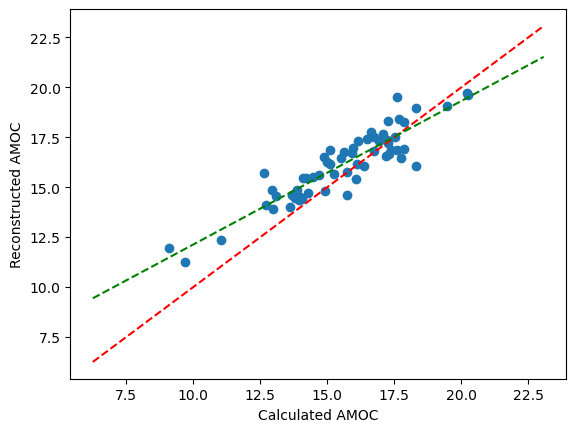

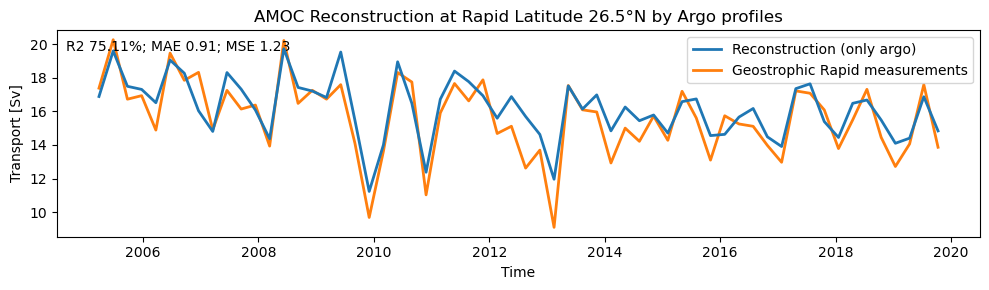

In [164]:
f'{r2_score(rapid_t.values, test_predictions_t.values)*100:.2f}% {mean_absolute_error(rapid_t.values, test_predictions_t.values):.2f} {mean_squared_error(rapid_t.values, test_predictions_t.values):.2f}'

'75.11% 0.91 1.23'

In [165]:
test_prediction_ds = xr.Dataset(
    {'test_predictions': test_predictions, 
     'test_gt_transport': test_gt_transport} ,

     attrs={
            'MAE': mae_error,
            'const_MAE': const_prediction_MAE,
            'R2': r2_score(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values),
            'MSE': mean_squared_error(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)
        } 
)
test_prediction_ds

<xarray.Dataset>
Dimensions:            (time: 60)
Coordinates:
  * time               (time) datetime64[ns] 2005-03-28 ... 2019-10-11
Data variables:
    test_predictions   (time) float32 16.89 19.6 17.49 ... 14.41 16.87 14.84
    test_gt_transport  (time) float32 17.38 20.27 16.73 ... 14.06 17.59 13.86
Attributes:
    MAE:        0.91192126
    const_MAE:  1.7984886
    R2:         0.7510743264004835
    MSE:        1.2346495

In [166]:
test_prediction_ds.to_netcdf(experiment_path / 'test_predictions.nc')

In [167]:
config_values = {
    'n_compartments': n_compartments,
    'n_embedding': n_embedding,
    'version': version,
    'distance_assignment_module': distance_assignment_module,
    'dataset_path': str(dataset_path),
    'target_reference_level': target_reference_level,
    'missing_values_in_target': missing_values_in_target,
    'using_missing_indices': using_missing_indices,
    'using_transport_from_previous_year': using_transport_from_previous_year,
    'add_tmp': add_tmp,
    'add_sal': add_sal,
    'random_split_data': random_split_data,
    'use_deep_dvdz': use_deep_dvdz,
    'mean_dv_dz_moorings': list(mean_dv_dz_moorings.values),
    'std_dv_dz_moorings': list(std_dv_dz_moorings.values),
    'train_batch_size': train_batch_size,
}
import json
with open(experiment_path / f'config.json', 'w') as f:
    json.dump(config_values, f)

In [168]:
# save best model 
torch.save(best_model.state_dict(), experiment_path / 'model.pt')

In [169]:
experiment_path

PosixPath('../rapid-geostrophic-reconstruction/figs/experiment_20250117_103241')

#### Improvemnt 

In [170]:
improvement_results = {
    'original': {
        'r2': float(r2_score(rapid_t.values, test_predictions_t.values)),
        'mae': float(mean_absolute_error(rapid_t.values, test_predictions_t.values)),
        'mse': float(mean_squared_error(rapid_t.values, test_predictions_t.values)),
    },        
}

R2: 0.5586638188935505, MAE: 1.1916230916976929, MSE: 2.188988447189331
R2: 0.5541715218818853, MAE: 1.2053377628326416, MSE: 2.211270332336426
R2: 0.5732488465555208, MAE: 1.170287847518921, MSE: 2.1166484355926514
R2: 0.5952036824732605, MAE: 1.1312158107757568, MSE: 2.00775408744812
R2: 0.5723821178311688, MAE: 1.1809078454971313, MSE: 2.1209473609924316
R2: 0.5319400819158743, MAE: 1.1579416990280151, MSE: 2.3215363025665283
R2: 0.5050437449570657, MAE: 1.2873671054840088, MSE: 2.454939842224121
R2: 0.564435049021737, MAE: 1.1732146739959717, MSE: 2.1603639125823975
R2: 0.5923635645163906, MAE: 1.0996994972229004, MSE: 2.021840810775757
R2: 0.5882294973900912, MAE: 1.1484276056289673, MSE: 2.0423455238342285
R2: 0.5635681925436545 ± 0.026735945944948967
MAE: 1.1746022701263428 ± 0.0473984032869339
MSE: 2.164663791656494 ± 0.13260804116725922


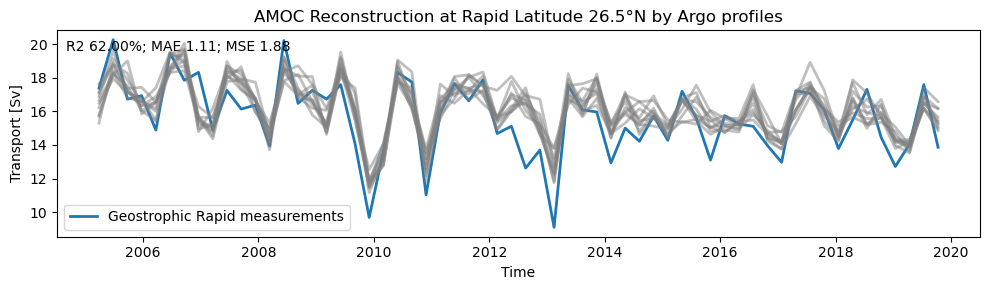

In [171]:

"""

Without Florid Strait Transport 

"""

n_iter = 10
n_test_samples = len(test_dataset)

r2s = []
maes = []
mses = []

predictions_wo_wsfc = []

for _ in range(n_iter):

    rand_indices_fc = np.arange(n_test_samples)
    np.random.shuffle(rand_indices_fc)

    test_dataset_wo_wsfc = ProfileDataset(test_X_scaled, test_y, test_y_prev_scaled, test_X_mask, test_X_lon, test_X_lat, test_dv_dz_moorings_scaled, test_X_days, compartments, test_missing_indices, test_fs_scaled[rand_indices_fc], test_ac_scaled, test_ws_scaled, test_total_moc_scaled)


    test_predictions_wo_wsfc, _ = make_predictions(test_dataset_wo_wsfc, best_model, test_indices)


    target_variable = total_moc_max

    def get_r2_mae_mse(target_variable, test_predictions):
        r2 = r2_score(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)
        mae = mean_absolute_error(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)
        mse = mean_squared_error(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)
        return r2, mae, mse


    r2, mae, mse = get_r2_mae_mse(target_variable, test_predictions_wo_wsfc)

    r2s.append(r2)
    maes.append(mae)
    mses.append(mse)

    predictions_wo_wsfc.append(test_predictions_wo_wsfc)

    print(f'R2: {r2}, MAE: {mae}, MSE: {mse}')

r2s = np.array(r2s)
maes = np.array(maes)
mses = np.array(mses)
predictions_wo_wsfc = np.array(predictions_wo_wsfc)

print(f'R2: {r2s.mean()} ± {r2s.std()}')
print(f'MAE: {maes.mean()} ± {maes.std()}')
print(f'MSE: {mses.mean()} ± {mses.std()}')


improvement_results['without_fc'] = {
    'r2_mean': float(r2s.mean()),
    'r2_std': float(r2s.std()),
    'mae_mean': float(maes.mean()),
    'mae_std': float(maes.std()),
    'mse_mean': float(mses.mean()),
    'mse_std': float(mses.std()),
}



fig = plt.figure(figsize=(10, 3))
ax = fig.add_subplot(1,1,1)

rapid = target_variable.sel(time = test_predictions.time, method = 'nearest')

test_predictions_t = predictions_wo_wsfc.mean(axis = 0)#.resample(time = '365D').mean()
rapid_t = rapid 

ax.plot( np.tile(rapid_t.time.values[np.newaxis], (n_iter,1)).T, predictions_wo_wsfc.T, 
        # label = 'Reconstruction (only argo)', 
        linewidth = 2, zorder = 20, alpha = .5, color = 'gray')
ax.plot(rapid_t.time, rapid_t.values, label = 'Geostrophic Rapid measurements', linewidth = 2)

plt.legend()
ax.set_ylabel('Transport [Sv]')
ax.set_xlabel('Time')

plt.text(0.01, 0.9,f'R2 {r2_score(rapid_t.values, test_predictions_t)*100:.2f}%; MAE {mean_absolute_error(rapid_t.values, test_predictions_t):.2f}; MSE {mean_squared_error(rapid_t.values, test_predictions_t):.2f}', transform=ax.transAxes)
plt.title('AMOC Reconstruction at Rapid Latitude 26.5°N by Argo profiles')
fig.tight_layout()
plt.savefig(experiment_path / f'argo_nn_reconstruction_wo_fc.png')


R2: 0.24786120003087908, MAE: 1.4806206226348877, MSE: 3.7305424213409424
R2: 0.2528785393147903, MAE: 1.5280390977859497, MSE: 3.7056570053100586
R2: 0.1855844668566271, MAE: 1.4959168434143066, MSE: 4.039429664611816
R2: 0.16403127347216262, MAE: 1.5196055173873901, MSE: 4.146331310272217
R2: 0.2381574276784798, MAE: 1.5219436883926392, MSE: 3.778672456741333
R2: 0.22934537114526388, MAE: 1.481933832168579, MSE: 3.8223793506622314
R2: 0.18377534426874387, MAE: 1.4832671880722046, MSE: 4.048402786254883
R2: 0.10919194512223118, MAE: 1.603564739227295, MSE: 4.41832971572876
R2: 0.3053486721760159, MAE: 1.328492522239685, MSE: 3.4454095363616943
R2: 0.2191247657209746, MAE: 1.4573222398757935, MSE: 3.873073101043701
R2: 0.21352990057861682 ± 0.05200806759314973
MAE: 1.4900705814361572 ± 0.0660504698753357
MSE: 3.900822401046753 ± 0.2579554319381714


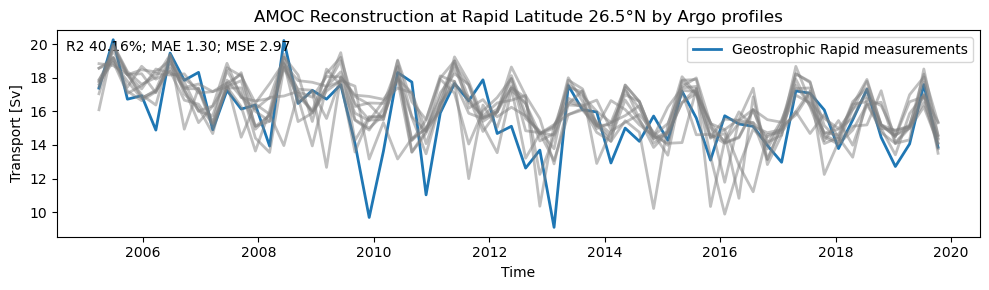

In [172]:

"""

Without Wind Stress

"""

n_iter = 10
n_test_samples = len(test_dataset)

r2s = []
maes = []
mses = []

predictions_wo_wsfc = []

for _ in range(n_iter):
    rand_indices_ws = np.arange(n_test_samples)
    np.random.shuffle(rand_indices_ws)


    test_dataset_wo_wsfc = ProfileDataset(test_X_scaled, test_y, test_y_prev_scaled, test_X_mask, test_X_lon, test_X_lat, test_dv_dz_moorings_scaled, test_X_days, compartments, test_missing_indices, test_fs_scaled, test_ac_scaled, test_ws_scaled[rand_indices_ws], test_total_moc_scaled)


    test_predictions_wo_wsfc, _ = make_predictions(test_dataset_wo_wsfc, best_model, test_indices)


    target_variable = total_moc_max

    def get_r2_mae_mse(target_variable, test_predictions):
        r2 = r2_score(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)
        mae = mean_absolute_error(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)
        mse = mean_squared_error(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)
        return r2, mae, mse


    r2, mae, mse = get_r2_mae_mse(target_variable, test_predictions_wo_wsfc)

    r2s.append(r2)
    maes.append(mae)
    mses.append(mse)

    predictions_wo_wsfc.append(test_predictions_wo_wsfc)

    print(f'R2: {r2}, MAE: {mae}, MSE: {mse}')

r2s = np.array(r2s)
maes = np.array(maes)
mses = np.array(mses)
predictions_wo_wsfc = np.array(predictions_wo_wsfc)

print(f'R2: {r2s.mean()} ± {r2s.std()}')
print(f'MAE: {maes.mean()} ± {maes.std()}')
print(f'MSE: {mses.mean()} ± {mses.std()}')

improvement_results['without_ws'] = {
    'r2_mean': float(r2s.mean()),
    'r2_std': float(r2s.std()),
    'mae_mean': float(maes.mean()),
    'mae_std': float(maes.std()),
    'mse_mean': float(mses.mean()),
    'mse_std': float(mses.std()),
}



fig = plt.figure(figsize=(10, 3))
ax = fig.add_subplot(1,1,1)

rapid = target_variable.sel(time = test_predictions.time, method = 'nearest')

test_predictions_t = predictions_wo_wsfc.mean(axis = 0)#.resample(time = '365D').mean()
rapid_t = rapid 

ax.plot( np.tile(rapid_t.time.values[np.newaxis], (n_iter,1)).T, predictions_wo_wsfc.T, 
        # label = 'Reconstruction (only argo)', 
        linewidth = 2, zorder = 20, alpha = .5, color = 'gray')
ax.plot(rapid_t.time, rapid_t.values, label = 'Geostrophic Rapid measurements', linewidth = 2)

plt.legend()
ax.set_ylabel('Transport [Sv]')
ax.set_xlabel('Time')

plt.text(0.01, 0.9,f'R2 {r2_score(rapid_t.values, test_predictions_t)*100:.2f}%; MAE {mean_absolute_error(rapid_t.values, test_predictions_t):.2f}; MSE {mean_squared_error(rapid_t.values, test_predictions_t):.2f}', transform=ax.transAxes)
plt.title('AMOC Reconstruction at Rapid Latitude 26.5°N by Argo profiles')
fig.tight_layout()
plt.savefig(experiment_path / f'argo_nn_reconstruction_wo_ws.png')


R2: 0.33140320899730746, MAE: 1.484150767326355, MSE: 3.3161816596984863
R2: 0.31123776980003415, MAE: 1.4733405113220215, MSE: 3.4162001609802246
R2: 0.27872351602211964, MAE: 1.5432783365249634, MSE: 3.5774686336517334
R2: 0.267980792276195, MAE: 1.5473490953445435, MSE: 3.630751371383667
R2: 0.3768017555155082, MAE: 1.4074397087097168, MSE: 3.0910086631774902
R2: 0.29816385247714494, MAE: 1.541115403175354, MSE: 3.481045722961426
R2: 0.4130234512849411, MAE: 1.4200814962387085, MSE: 2.9113519191741943
R2: 0.43291566031410156, MAE: 1.38168203830719, MSE: 2.8126885890960693
R2: 0.37874902525327125, MAE: 1.4796444177627563, MSE: 3.081350803375244
R2: 0.4488204702684203, MAE: 1.3827836513519287, MSE: 2.733802556991577
R2: 0.3537819502209044 ± 0.06193309412408422
MAE: 1.4660866260528564 ± 0.061946481466293335
MSE: 3.2051849365234375 ± 0.30718275904655457


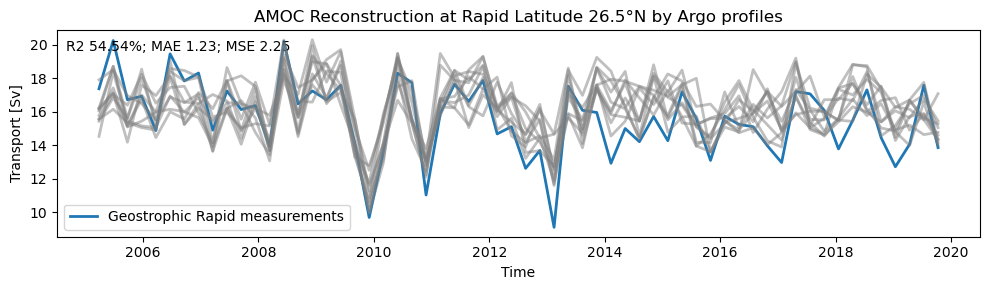

In [173]:

"""

Without Argo 

"""

n_iter = 10
n_test_samples = len(test_dataset)

r2s = []
maes = []
mses = []

predictions_wo_arac = []

for _ in range(n_iter):
    rand_indices_argo = np.arange(n_test_samples)
    np.random.shuffle(rand_indices_argo)


    test_dataset_wo_arac = ProfileDataset(test_X_scaled[rand_indices_argo], test_y, test_y_prev_scaled, test_X_mask[rand_indices_argo], test_X_lon[rand_indices_argo], test_X_lat[rand_indices_argo], test_dv_dz_moorings_scaled[rand_indices_argo], test_X_days[rand_indices_argo], compartments, test_missing_indices[rand_indices_argo], test_fs_scaled, test_ac_scaled, test_ws_scaled, test_total_moc_scaled)


    test_predictions_wo_arac, _ = make_predictions(test_dataset_wo_arac, best_model, test_indices)


    target_variable = total_moc_max

    def get_r2_mae_mse(target_variable, test_predictions):
        r2 = r2_score(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)
        mae = mean_absolute_error(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)
        mse = mean_squared_error(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)
        return r2, mae, mse


    r2, mae, mse = get_r2_mae_mse(target_variable, test_predictions_wo_arac)

    r2s.append(r2)
    maes.append(mae)
    mses.append(mse)

    

    predictions_wo_arac.append(test_predictions_wo_arac)

    print(f'R2: {r2}, MAE: {mae}, MSE: {mse}')

r2s = np.array(r2s)
maes = np.array(maes)
mses = np.array(mses)
predictions_wo_arac = np.array(predictions_wo_arac)

print(f'R2: {r2s.mean()} ± {r2s.std()}')
print(f'MAE: {maes.mean()} ± {maes.std()}')
print(f'MSE: {mses.mean()} ± {mses.std()}')

improvement_results['without_argo'] = {
        'r2_mean': float(r2s.mean()),
        'r2_std': float(r2s.std()),
        'mae_mean': float(maes.mean()),
        'mae_std': float(maes.std()),
        'mse_mean': float(mses.mean()),
        'mse_std': float(mses.std()),
    }


fig = plt.figure(figsize=(10, 3))
ax = fig.add_subplot(1,1,1)

rapid = target_variable.sel(time = test_predictions.time, method = 'nearest')

test_predictions_t = predictions_wo_arac.mean(axis = 0)#.resample(time = '365D').mean()
rapid_t = rapid 

# repeat rapid_t.time in a new first dimension 10 times


ax.plot( np.tile(rapid_t.time.values[np.newaxis], (n_iter,1)).T, predictions_wo_arac.T, 
        # label = 'Reconstruction (only argo)', 
        linewidth = 2, zorder = 20, c = 'gray', alpha = .5)
ax.plot(rapid_t.time, rapid_t.values, label = 'Geostrophic Rapid measurements', linewidth = 2)

plt.legend()
ax.set_ylabel('Transport [Sv]')
ax.set_xlabel('Time')

plt.text(0.01, 0.9,f'R2 {r2_score(rapid_t.values, test_predictions_t)*100:.2f}%; MAE {mean_absolute_error(rapid_t.values, test_predictions_t):.2f}; MSE {mean_squared_error(rapid_t.values, test_predictions_t):.2f}', transform=ax.transAxes)
plt.title('AMOC Reconstruction at Rapid Latitude 26.5°N by Argo profiles')
fig.tight_layout()
plt.savefig(experiment_path / f'argo_nn_reconstruction_wo_ar.png')

R2: 0.6922252509029887, MAE: 1.0044525861740112, MSE: 1.5265358686447144
R2: 0.686971795249746, MAE: 1.0093692541122437, MSE: 1.5525925159454346
R2: 0.7043150674015385, MAE: 0.9987620115280151, MSE: 1.4665714502334595
R2: 0.6738128273142615, MAE: 1.0546085834503174, MSE: 1.6178597211837769
R2: 0.7248173555139101, MAE: 0.9226528406143188, MSE: 1.3648817539215088
R2: 0.681195753385172, MAE: 1.016424536705017, MSE: 1.5812411308288574
R2: 0.6757987817709536, MAE: 1.0246155261993408, MSE: 1.608009696006775
R2: 0.6759448003484996, MAE: 1.0216643810272217, MSE: 1.6072852611541748
R2: 0.6721591306419792, MAE: 1.0549918413162231, MSE: 1.626062035560608
R2: 0.6604923838974405, MAE: 1.0514943599700928, MSE: 1.6839280128479004
R2: 0.6847733146426489 ± 0.017566636983176363
MAE: 1.0159035921096802 ± 0.036831218749284744
MSE: 1.5634968280792236 ± 0.08712897449731827


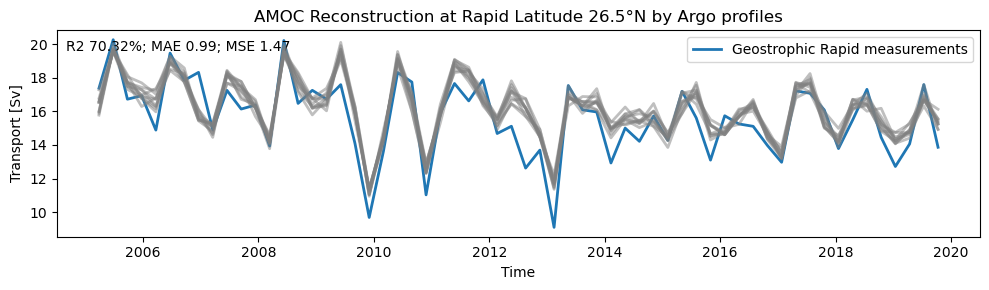

In [174]:

"""

Without Antilles Current 

"""

n_iter = 10
n_test_samples = len(test_dataset)

r2s = []
maes = []
mses = []

predictions_wo_arac = []

for _ in range(n_iter):
    rand_indices_argo = np.arange(n_test_samples)
    np.random.shuffle(rand_indices_argo)

    rand_indices_ac = np.arange(n_test_samples)
    np.random.shuffle(rand_indices_ac)


    test_dataset_wo_arac = ProfileDataset(test_X_scaled, test_y, test_y_prev_scaled, test_X_mask, test_X_lon, test_X_lat, test_dv_dz_moorings_scaled, test_X_days, compartments, test_missing_indices, test_fs_scaled, test_ac_scaled[rand_indices_ac], test_ws_scaled, test_total_moc_scaled)


    test_predictions_wo_arac, _ = make_predictions(test_dataset_wo_arac, best_model, test_indices)


    target_variable = total_moc_max

    def get_r2_mae_mse(target_variable, test_predictions):
        r2 = r2_score(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)
        mae = mean_absolute_error(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)
        mse = mean_squared_error(target_variable.sel(time = test_predictions.time, method = "nearest").values, test_predictions.values)
        return r2, mae, mse


    r2, mae, mse = get_r2_mae_mse(target_variable, test_predictions_wo_arac)

    r2s.append(r2)
    maes.append(mae)
    mses.append(mse)

    

    predictions_wo_arac.append(test_predictions_wo_arac)

    print(f'R2: {r2}, MAE: {mae}, MSE: {mse}')

r2s = np.array(r2s)
maes = np.array(maes)
mses = np.array(mses)
predictions_wo_arac = np.array(predictions_wo_arac)

print(f'R2: {r2s.mean()} ± {r2s.std()}')
print(f'MAE: {maes.mean()} ± {maes.std()}')
print(f'MSE: {mses.mean()} ± {mses.std()}')

improvement_results['without_ac'] = {
        'r2_mean': float(r2s.mean()),
        'r2_std': float(r2s.std()),
        'mae_mean': float(maes.mean()),
        'mae_std': float(maes.std()),
        'mse_mean': float(mses.mean()),
        'mse_std': float(mses.std()),
    }


fig = plt.figure(figsize=(10, 3))
ax = fig.add_subplot(1,1,1)

rapid = target_variable.sel(time = test_predictions.time, method = 'nearest')

test_predictions_t = predictions_wo_arac.mean(axis = 0)#.resample(time = '365D').mean()
rapid_t = rapid 

# repeat rapid_t.time in a new first dimension 10 times


ax.plot( np.tile(rapid_t.time.values[np.newaxis], (n_iter,1)).T, predictions_wo_arac.T, 
        # label = 'Reconstruction (only argo)', 
        linewidth = 2, zorder = 20, c = 'gray', alpha = .5)
ax.plot(rapid_t.time, rapid_t.values, label = 'Geostrophic Rapid measurements', linewidth = 2)

plt.legend()
ax.set_ylabel('Transport [Sv]')
ax.set_xlabel('Time')

plt.text(0.01, 0.9,f'R2 {r2_score(rapid_t.values, test_predictions_t)*100:.2f}%; MAE {mean_absolute_error(rapid_t.values, test_predictions_t):.2f}; MSE {mean_squared_error(rapid_t.values, test_predictions_t):.2f}', transform=ax.transAxes)
plt.title('AMOC Reconstruction at Rapid Latitude 26.5°N by Argo profiles')
fig.tight_layout()
plt.savefig(experiment_path / f'argo_nn_reconstruction_wo_ac.png')

In [175]:
# save improvement results as json

with open(experiment_path / 'improvement_results.json', 'w') as f:
    json.dump(improvement_results, f)
    

#### Importance of clusters

In [176]:
## Execute the test dataset and permute every time one of the clusters.

In [177]:
test_X_hat = torch.concat([one[0] for one in test_inner_values ], dim = 0)
test_embedding_all_profiles = torch.concat([one[1] for one in test_inner_values ], dim = 0)
test_total_moc = torch.concat([one[2] for one in test_inner_values ], dim = 0)

n_samples = test_X_hat.shape[0]
n_iter = 50

compartment_losses = []
compartment_maes = []
compartment_r2s = []

for compartment_i in range(-1, n_compartments ):
    test_losses = []

    test_maes = []
    test_r2s = []
    for _ in range(n_iter):

        X_hat_permuted = test_X_hat.clone()
        embedding_all_profiles = test_embedding_all_profiles.clone()
        if compartment_i >= 0 :
            rand_indices = np.arange(n_samples)
            np.random.shuffle(rand_indices)

            X_hat_permuted[:, compartment_i] = X_hat_permuted[rand_indices, compartment_i]


            embedding_all_profiles[:, :n_compartments * n_embedding] =  X_hat_permuted.reshape(n_test_samples, -1)

        
        x = torch.relu(best_model.fc1(embedding_all_profiles))
        # x = torch.relu(best_model.fc5(x))
        x = best_model.fc6(x)
        x = x.squeeze(dim = -1)


        test_loss = criterion(x, test_total_moc).item()

        prediction_transport = x * std_total_moc.values[()] + mean_total_moc.values[()]

        mae = mean_absolute_error(test_gt_transport.values, prediction_transport.detach().cpu().numpy())
        r2 = r2_score(test_gt_transport.values, prediction_transport.detach().cpu().numpy())
        
        test_maes.append(mae)
        test_losses.append(test_loss)
        test_r2s.append(r2)


    compartment_losses.append(np.mean(test_losses))
    compartment_maes.append(np.mean(test_maes))
    compartment_r2s.append(np.mean(test_r2s))
    print(f'Permute cluster {compartment_i} for loss {compartment_losses[-1]:.3f} decrease {(compartment_losses[-1] - compartment_losses[0]) / compartment_losses[0] * 100:.2f}% for mae {compartment_maes[-1]:.3f} decrease {(compartment_maes[-1] - compartment_maes[0]) / compartment_maes[0] * 100:.2f}% for r2 {compartment_r2s[-1]:.3f} increase {(compartment_r2s[-1] - compartment_r2s[0]) / compartment_r2s[0] * 100:.2f}%')

RuntimeError: torch.cat(): expected a non-empty list of Tensors

In [ ]:
best_model.node_assigner.centers

Parameter containing:
tensor([[0.4644, 0.4667, 0.4937]])

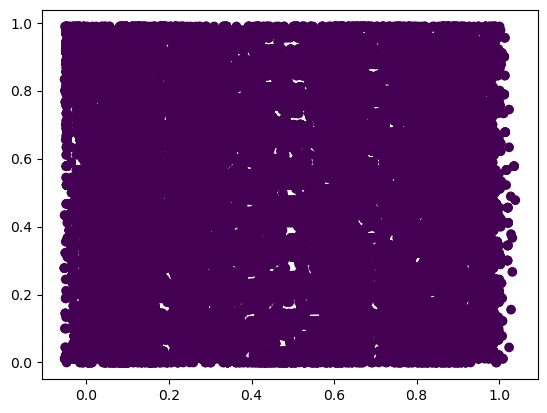

In [ ]:
a = torch.tensor(np.stack(
    [test_dataset.lon_scaled,
    test_dataset.lat_scaled,
    test_dataset.days_scaled,],
    axis = -1))
b = a[~torch.isnan(a).any(dim = -1)]


fig = plt.figure()
ax = fig.add_subplot(1,1,1)


ax.scatter(b[:, 0], b[:, 2], c = np.argmax(best_model.node_assigner(b), axis = -1))